In [3]:
import os
import json
import zipfile
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, learning_curve
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import joblib

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
DATASET_ZIP = Path(r"C:\Users\User\Desktop\ARGUS_V6\dataset_Figma_v2.zip")

OUTPUT_DIR = Path("argus_model_outputs")
CHART_DIR = OUTPUT_DIR / "charts"
MODEL_DIR = OUTPUT_DIR / "model_files"

OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print("Dataset path:", DATASET_ZIP)
print("Output folder:", OUTPUT_DIR.resolve())

if DATASET_ZIP.exists():
    print("Dataset found.")
else:
    print("Dataset not found. Please check DATASET_ZIP path.")

Dataset path: C:\Users\User\Desktop\ARGUS_V6\dataset_Figma_v2.zip
Output folder: C:\Users\User\Desktop\ARGUS_V6\Argus_Project _V6\argus_backend\ml_training\argus_model_outputs
Dataset found.


In [5]:
with zipfile.ZipFile(DATASET_ZIP, "r") as z:
    all_files = z.namelist()

print("Total files inside zip:", len(all_files))

print("\nFirst 30 files:")
for file in all_files[:30]:
    print(file)

print("\nTop-level folders:")
top_folders = sorted(set(path.split("/")[0] for path in all_files if "/" in path))
print(top_folders)

Total files inside zip: 240013

First 30 files:
dataset_Figma/
dataset_Figma/annotations/
dataset_Figma/annotations/color/
dataset_Figma/annotations/color/color_00001_annotation.json
dataset_Figma/annotations/color/color_00002_annotation.json
dataset_Figma/annotations/color/color_00003_annotation.json
dataset_Figma/annotations/color/color_00004_annotation.json
dataset_Figma/annotations/color/color_00005_annotation.json
dataset_Figma/annotations/color/color_00006_annotation.json
dataset_Figma/annotations/color/color_00007_annotation.json
dataset_Figma/annotations/color/color_00008_annotation.json
dataset_Figma/annotations/color/color_00009_annotation.json
dataset_Figma/annotations/color/color_00010_annotation.json
dataset_Figma/annotations/color/color_00011_annotation.json
dataset_Figma/annotations/color/color_00012_annotation.json
dataset_Figma/annotations/color/color_00013_annotation.json
dataset_Figma/annotations/color/color_00014_annotation.json
dataset_Figma/annotations/color/color

In [6]:
stats_path = "dataset_Figma/statistics/overall_statistics.json"

with zipfile.ZipFile(DATASET_ZIP, "r") as z:
    if stats_path in z.namelist():
        stats = json.loads(z.read(stats_path))
        print(json.dumps(stats, indent=2))
    else:
        print("overall_statistics.json not found. Continuing without it.")

{
  "generatedAt": "2026-07-30T12:43:12.640Z",
  "datasetVersion": "1.0.0",
  "author": "Chamath Perera",
  "description": "Synthetic Figma UI Design Dataset for UI/UX Heuristic Issue Detection",
  "totalDesigns": 120000,
  "datasetsGenerated": 4,
  "datasets": {
    "normal": {
      "generated": 30000,
      "percentage": 25,
      "outputDirectory": "C:\\Users\\USER\\OneDrive\\Documents\\figma_dataset_generator\\output\\designs\\normal"
    },
    "color": {
      "generated": 30000,
      "percentage": 25,
      "outputDirectory": "C:\\Users\\USER\\OneDrive\\Documents\\figma_dataset_generator\\output\\designs\\color"
    },
    "error": {
      "generated": 30000,
      "percentage": 25,
      "outputDirectory": "C:\\Users\\USER\\OneDrive\\Documents\\figma_dataset_generator\\output\\designs\\error"
    },
    "layout": {
      "generated": 30000,
      "percentage": 25,
      "outputDirectory": "C:\\Users\\USER\\OneDrive\\Documents\\figma_dataset_generator\\output\\designs\\layout"

In [8]:
FEATURE_COLUMNS = [
    "nodeCount", "screenWidth", "screenHeight", "screenArea",
    "isModalLike", "modalConfidence", "hasExitControl", "hasDestructiveAction",
    "hasUndoOption", "hasConfirmationDialog", "interactiveElementCount", "textElementCount",
    "errorElementCount", "buttonCount", "inputCount", "controlDensity", "textDensity",
    "averageSpacing", "spacingDeviation", "maxSpacingGap", "alignmentDeviation",
    "misalignedElementCount", "cornerRadiusDeviation", "buttonHeightDeviation",
    "buttonWidthDeviation", "buttonAspectRatioDeviation", "colorCount", "actionColorCount",
    "sameActionColorDeviation", "differentActionSameColorScore", "colorPatternDeviation",
    "errorContrastRatio", "errorVisibilityScore", "backgroundContrastAverage",
    "destructiveActionCount", "confirmationControlCount", "layoutGroupSize", "overlayPresent",
    "module_layout", "module_color", "module_error", "module_normal"
]

LABEL_MAP = {
    "normal": "no_issue",
    "missing_exit": "missing_exit_control",
    "missing_undo": "destructive_without_undo",
    "missing_confirmation": "irreversible_without_confirmation"
}

SEVERITY_MAP = {
    "no_issue": "low",
    "missing_exit_control": "high",
    "destructive_without_undo": "high",
    "irreversible_without_confirmation": "high",
    "spacing_inconsistency": "medium",
    "button_shape_inconsistency": "medium",
    "alignment_inconsistency": "medium",
    "overloaded_screen": "medium",
    "color_inconsistency": "medium",
    "same_color_different_actions": "medium",
    "weak_error_visibility": "medium"
}

SUGGESTION_MAP = {
    "no_issue": "no_action_needed",
    "missing_exit_control": "add_back_cancel_or_close",
    "spacing_inconsistency": "standardize_spacing",
    "button_shape_inconsistency": "standardize_component_shape",
    "alignment_inconsistency": "align_to_common_layout_pattern",
    "overloaded_screen": "reduce_density_and_group_controls",
    "color_inconsistency": "standardize_action_color",
    "same_color_different_actions": "differentiate_action_colors",
    "weak_error_visibility": "improve_error_state_visibility",
    "destructive_without_undo": "add_undo_or_recovery_option",
    "irreversible_without_confirmation": "add_confirmation_step"
}

print("Number of feature columns:", len(FEATURE_COLUMNS))
print("Severity mapping classes:", len(SEVERITY_MAP))
print("Suggestion mapping classes:", len(SUGGESTION_MAP))

Number of feature columns: 42
Severity mapping classes: 11
Suggestion mapping classes: 11


In [9]:
EXIT_KEYWORDS = ["close", "cancel", "back", "exit", "dismiss", "x", "return", "go back"]

MODAL_KEYWORDS = ["modal", "dialog", "popup", "overlay", "confirmation", "confirm", "alert"]

BUTTON_HINTS = [
    "button", "btn", "submit", "save", "continue", "next", "cancel",
    "delete", "remove", "reset", "confirm", "login", "register",
    "create", "restore", "apply", "update", "send", "pay"
]

DESTRUCTIVE_KEYWORDS = [
    "delete", "remove", "discard", "reset", "erase", "clear",
    "deactivate", "disable", "logout", "sign out", "permanent", "destroy"
]

CONFIRMATION_KEYWORDS = [
    "confirm", "confirmation", "are you sure", "warning",
    "cannot be undone", "proceed"
]

UNDO_KEYWORDS = ["undo", "restore", "recover", "revert", "rollback"]

ERROR_KEYWORDS = [
    "error", "invalid", "wrong", "required", "failed", "failure",
    "warning", "try again", "danger", "alert", "not allowed"
]

ACTION_KEYWORDS = [
    "login", "register", "submit", "save", "continue", "next",
    "confirm", "delete", "remove", "reset", "cancel", "restore",
    "apply", "update", "create", "send", "pay"
]

print("Keyword groups ready.")

Keyword groups ready.


In [10]:
def safe_number(value):
    try:
        if value is None:
            return 0.0
        value = float(value)
        if np.isnan(value) or np.isinf(value):
            return 0.0
        return value
    except:
        return 0.0


def normalize_text(value):
    return str(value or "").lower().strip()


def node_label(node):
    return normalize_text(
        f"{node.get('name', '')} {node.get('text', '')} {node.get('iconName', '')}"
    )


def contains_any(text, keywords):
    text = normalize_text(text)
    return any(keyword in text for keyword in keywords)


def get_color(node):
    color = node.get("fillColor")

    if isinstance(color, dict) and "r" in color:
        return {
            "r": round(safe_number(color.get("r"))),
            "g": round(safe_number(color.get("g"))),
            "b": round(safe_number(color.get("b")))
        }

    return None


def color_key(color, bucket_size=16):
    if not color:
        return None

    return (
        round(color["r"] / bucket_size) * bucket_size,
        round(color["g"] / bucket_size) * bucket_size,
        round(color["b"] / bucket_size) * bucket_size
    )


def color_distance(a, b):
    if not a or not b:
        return 0.0

    return np.sqrt(
        (safe_number(a["r"]) - safe_number(b["r"])) ** 2 +
        (safe_number(a["g"]) - safe_number(b["g"])) ** 2 +
        (safe_number(a["b"]) - safe_number(b["b"])) ** 2
    )


def luminance(color):
    if not color:
        return 0.0

    values = []

    for channel in ["r", "g", "b"]:
        c = safe_number(color[channel]) / 255.0
        if c <= 0.03928:
            values.append(c / 12.92)
        else:
            values.append(((c + 0.055) / 1.055) ** 2.4)

    return 0.2126 * values[0] + 0.7152 * values[1] + 0.0722 * values[2]


def contrast_ratio(foreground, background):
    if not foreground or not background:
        return 0.0

    l1 = luminance(foreground)
    l2 = luminance(background)

    lighter = max(l1, l2)
    darker = min(l1, l2)

    return round((lighter + 0.05) / (darker + 0.05), 2)


print("Helper functions ready.")

Helper functions ready.


In [11]:
def is_button_like(node):
    node_type = normalize_text(node.get("type"))
    label = node_label(node)

    return (
        node_type in ["button", "rectangle", "instance", "component"] or
        contains_any(label, BUTTON_HINTS) or
        "button" in normalize_text(node.get("componentId")) or
        "button" in normalize_text(node.get("mainComponentId"))
    )


def is_input_like(node):
    node_type = normalize_text(node.get("type"))
    label = node_label(node)

    return (
        node_type == "input" or
        "input" in label or
        "field" in label or
        "input" in normalize_text(node.get("componentId"))
    )


def is_exit_control(node):
    label = node_label(node)
    return contains_any(label, EXIT_KEYWORDS) or node.get("hasCloseButton") is True


def is_destructive_action(node):
    return contains_any(node_label(node), DESTRUCTIVE_KEYWORDS)


def is_confirmation_control(node):
    return contains_any(node_label(node), CONFIRMATION_KEYWORDS)


def is_undo_control(node):
    return contains_any(node_label(node), UNDO_KEYWORDS)


def is_error_node(node):
    return contains_any(node_label(node), ERROR_KEYWORDS)


def get_action_type(node):
    label = node_label(node)

    for keyword in ACTION_KEYWORDS:
        if keyword in label:
            return keyword

    return None


def is_interactive(node):
    return (
        is_button_like(node) or
        is_input_like(node) or
        is_exit_control(node) or
        get_action_type(node) is not None
    )


def is_modal_like(node):
    node_type = normalize_text(node.get("type"))
    label = node_label(node)

    return (
        node_type in ["modal", "overlay", "dialog"] or
        node.get("overlay") is True or
        contains_any(label, MODAL_KEYWORDS)
    )


print("Node classification helpers ready.")

Node classification helpers ready.


In [12]:
def extract_features_from_design(design, annotation):
    nodes = design.get("nodes", [])
    nodes = [node for node in nodes if node and node.get("visible", True) is not False]

    if len(nodes) == 0:
        nodes = []

    root = nodes[0] if len(nodes) > 0 else {}

    screen_width = safe_number(root.get("width"))
    screen_height = safe_number(root.get("height"))
    screen_area = max(screen_width * screen_height, 1)

    node_count = len(nodes)

    text_nodes = [n for n in nodes if normalize_text(n.get("type")) == "text"]
    button_nodes = [n for n in nodes if is_button_like(n)]
    input_nodes = [n for n in nodes if is_input_like(n)]
    interactive_nodes = [n for n in nodes if is_interactive(n)]
    error_nodes = [n for n in nodes if is_error_node(n)]
    destructive_nodes = [n for n in nodes if is_destructive_action(n)]
    confirmation_nodes = [n for n in nodes if is_confirmation_control(n)]
    undo_nodes = [n for n in nodes if is_undo_control(n)]
    exit_nodes = [n for n in nodes if is_exit_control(n)]
    modal_nodes = [n for n in nodes if is_modal_like(n)]

    # Spacing features
    spacing_values = [
        safe_number(n.get("itemSpacing"))
        for n in nodes
        if n.get("itemSpacing") is not None
    ]

    if len(spacing_values) > 0:
        average_spacing = np.mean(spacing_values)
        spacing_deviation = np.std(spacing_values)
        max_spacing_gap = np.max(spacing_values) - np.min(spacing_values)
    else:
        average_spacing = 0
        spacing_deviation = 0
        max_spacing_gap = 0

    # Position and alignment features
    x_values = np.array([safe_number(n.get("x")) for n in nodes])
    y_values = np.array([safe_number(n.get("y")) for n in nodes])

    if len(x_values) > 1:
        alignment_deviation = np.std(x_values) + np.std(y_values)
        rounded_x = [round(x / 10) * 10 for x in x_values]
        common_x = Counter(rounded_x).most_common(1)[0][0]
        misaligned_count = sum(abs(x - common_x) > 20 for x in x_values)
    else:
        alignment_deviation = 0
        misaligned_count = 0

    # Shape consistency features
    corner_values = [
        safe_number(n.get("cornerRadius"))
        for n in nodes
        if n.get("cornerRadius") is not None
    ]

    corner_radius_deviation = np.std(corner_values) if len(corner_values) > 1 else 0

    button_heights = [safe_number(n.get("height")) for n in button_nodes]
    button_widths = [safe_number(n.get("width")) for n in button_nodes]

    button_height_deviation = np.std(button_heights) if len(button_heights) > 1 else 0
    button_width_deviation = np.std(button_widths) if len(button_widths) > 1 else 0

    aspect_ratios = []
    for n in button_nodes:
        width = safe_number(n.get("width"))
        height = safe_number(n.get("height"))
        if height > 0:
            aspect_ratios.append(width / height)

    button_aspect_ratio_deviation = np.std(aspect_ratios) if len(aspect_ratios) > 1 else 0

    # Color features
    colors = [get_color(n) for n in nodes]
    colors = [c for c in colors if c is not None]
    color_buckets = [color_key(c) for c in colors]
    color_buckets = [c for c in color_buckets if c is not None]

    color_count = len(set(color_buckets))

    if len(color_buckets) > 0:
        dominant_color_count = Counter(color_buckets).most_common(1)[0][1]
        color_pattern_deviation = 1 - (dominant_color_count / len(color_buckets))
    else:
        color_pattern_deviation = 0

    # Action color relationship features
    action_colors = defaultdict(list)

    for node in nodes:
        action = get_action_type(node)
        color = get_color(node)

        if action and color:
            action_colors[action].append(color_key(color))

    action_color_count = len(action_colors)

    same_action_color_deviation = 0
    for action, action_color_list in action_colors.items():
        same_action_color_deviation += len(set(action_color_list)) - 1

    color_to_actions = defaultdict(set)

    for action, action_color_list in action_colors.items():
        for c in action_color_list:
            color_to_actions[c].add(action)

    different_action_same_color_score = sum(
        len(actions) - 1
        for actions in color_to_actions.values()
        if len(actions) > 1
    )

    # Error visibility features
    background_color = get_color(root) or {"r": 255, "g": 255, "b": 255}

    error_contrasts = []

    for node in error_nodes:
        color = get_color(node)

        if color:
            error_contrasts.append(contrast_ratio(color, background_color))

    error_contrast_ratio = np.mean(error_contrasts) if len(error_contrasts) > 0 else 0

    if len(error_contrasts) > 0:
        error_visibility_score = 1 if error_contrast_ratio < 4.5 else 0
    else:
        error_visibility_score = 0

    # Layout grouping
    parent_ids = [n.get("parentId") for n in nodes if n.get("parentId")]
    layout_group_size = len(set(parent_ids))

    overlay_present = 1 if any(n.get("overlay") is True for n in nodes) else 0

    category = annotation.get("category", "normal")
    raw_label = annotation.get("expectedLabel", annotation.get("mutation", "normal"))
    issue_label = LABEL_MAP.get(raw_label, raw_label)

    severity = SEVERITY_MAP.get(issue_label, "medium")
    suggestion_category = SUGGESTION_MAP.get(issue_label, "review_ui_pattern")

    row = {
        "designId": annotation.get("designId"),
        "category": category,
        "screenType": annotation.get("screenType"),
        "theme": annotation.get("theme"),
        "issueLabel": issue_label,
        "severity": severity,
        "suggestionCategory": suggestion_category,

        "nodeCount": node_count,
        "screenWidth": screen_width,
        "screenHeight": screen_height,
        "screenArea": screen_area,

        "isModalLike": 1 if len(modal_nodes) > 0 else 0,
        "modalConfidence": min(len(modal_nodes) / 3, 1),
        "hasExitControl": 1 if len(exit_nodes) > 0 else 0,
        "hasDestructiveAction": 1 if len(destructive_nodes) > 0 else 0,
        "hasUndoOption": 1 if len(undo_nodes) > 0 else 0,
        "hasConfirmationDialog": 1 if len(confirmation_nodes) > 0 else 0,

        "interactiveElementCount": len(interactive_nodes),
        "textElementCount": len(text_nodes),
        "errorElementCount": len(error_nodes),
        "buttonCount": len(button_nodes),
        "inputCount": len(input_nodes),

        "controlDensity": len(interactive_nodes) / screen_area * 100000,
        "textDensity": len(text_nodes) / screen_area * 100000,

        "averageSpacing": average_spacing,
        "spacingDeviation": spacing_deviation,
        "maxSpacingGap": max_spacing_gap,

        "alignmentDeviation": alignment_deviation,
        "misalignedElementCount": misaligned_count,

        "cornerRadiusDeviation": corner_radius_deviation,
        "buttonHeightDeviation": button_height_deviation,
        "buttonWidthDeviation": button_width_deviation,
        "buttonAspectRatioDeviation": button_aspect_ratio_deviation,

        "colorCount": color_count,
        "actionColorCount": action_color_count,
        "sameActionColorDeviation": same_action_color_deviation,
        "differentActionSameColorScore": different_action_same_color_score,
        "colorPatternDeviation": color_pattern_deviation,

        "errorContrastRatio": error_contrast_ratio,
        "errorVisibilityScore": error_visibility_score,
        "backgroundContrastAverage": error_contrast_ratio,

        "destructiveActionCount": len(destructive_nodes),
        "confirmationControlCount": len(confirmation_nodes),
        "layoutGroupSize": layout_group_size,
        "overlayPresent": overlay_present,

        "module_layout": 1 if category == "layout" else 0,
        "module_color": 1 if category == "color" else 0,
        "module_error": 1 if category == "error" else 0,
        "module_normal": 1 if category == "normal" else 0
    }

    return row


print("Feature extraction function ready.")

Feature extraction function ready.


In [13]:
CATEGORIES = ["normal", "layout", "color", "error"]

MAX_PER_CATEGORY = None

rows = []

with zipfile.ZipFile(DATASET_ZIP, "r") as z:
    zip_names = z.namelist()

    for category in CATEGORIES:
        annotation_prefix = f"dataset_Figma/annotations/{category}/"

        annotation_files = [
            file for file in zip_names
            if file.startswith(annotation_prefix) and file.endswith("_annotation.json")
        ]

        annotation_files = sorted(annotation_files)

        if MAX_PER_CATEGORY is not None:
            annotation_files = annotation_files[:MAX_PER_CATEGORY]

        print(f"Reading {len(annotation_files)} annotation files from category: {category}")

        for index, annotation_path in enumerate(annotation_files):
            annotation = json.loads(z.read(annotation_path))

            design_id = annotation["designId"]
            design_path = f"dataset_Figma/designs/{category}/{design_id}.json"

            if design_path not in zip_names:
                continue

            design = json.loads(z.read(design_path))

            row = extract_features_from_design(design, annotation)
            rows.append(row)

            if (index + 1) % 5000 == 0:
                print(f"  {category}: {index + 1} processed")

df = pd.DataFrame(rows)

print("\nDataset created.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

Reading 30000 annotation files from category: normal
  normal: 5000 processed
  normal: 10000 processed
  normal: 15000 processed
  normal: 20000 processed
  normal: 25000 processed
  normal: 30000 processed
Reading 30000 annotation files from category: layout
  layout: 5000 processed
  layout: 10000 processed
  layout: 15000 processed
  layout: 20000 processed
  layout: 25000 processed
  layout: 30000 processed
Reading 30000 annotation files from category: color
  color: 5000 processed
  color: 10000 processed
  color: 15000 processed
  color: 20000 processed
  color: 25000 processed
  color: 30000 processed
Reading 30000 annotation files from category: error
  error: 5000 processed
  error: 10000 processed
  error: 15000 processed
  error: 20000 processed
  error: 25000 processed
  error: 30000 processed

Dataset created.
Rows: 120000
Columns: 49


,designId,category,screenType,theme,issueLabel,severity,suggestionCategory,nodeCount,screenWidth,screenHeight,...,errorVisibilityScore,backgroundContrastAverage,destructiveActionCount,confirmationControlCount,layoutGroupSize,overlayPresent,module_layout,module_color,module_error,module_normal
0,normal_00001,normal,register,Purple,no_issue,low,no_action_needed,15,412.0,915.0,...,0,0,0,0,1,0,0,0,0,1
1,normal_00002,normal,register,Dark,no_issue,low,no_action_needed,15,390.0,844.0,...,0,0,0,0,1,0,0,0,0,1
2,normal_00003,normal,register,Green,no_issue,low,no_action_needed,15,430.0,932.0,...,0,0,0,0,1,0,0,0,0,1
3,normal_00004,normal,register,Orange,no_issue,low,no_action_needed,15,430.0,932.0,...,0,0,0,0,1,0,0,0,0,1
4,normal_00005,normal,register,Green,no_issue,low,no_action_needed,15,390.0,844.0,...,0,0,0,0,1,0,0,0,0,1


In [14]:
CSV_PATH = OUTPUT_DIR / "argus_training_dataset.csv"
df.to_csv(CSV_PATH, index=False)

print("Saved extracted dataset to:", CSV_PATH.resolve())

Saved extracted dataset to: C:\Users\User\Desktop\ARGUS_V6\Argus_Project _V6\argus_backend\ml_training\argus_model_outputs\argus_training_dataset.csv


In [15]:
print("Dataset shape:", df.shape)

print("\nIssue label counts:")
display(df["issueLabel"].value_counts())

print("\nSeverity counts:")
display(df["severity"].value_counts())

print("\nSuggestion category counts:")
display(df["suggestionCategory"].value_counts())

print("\nMissing values per feature:")
display(df[FEATURE_COLUMNS].isna().sum().sort_values(ascending=False).head(20))

Dataset shape: (120000, 49)

Issue label counts:


issueLabel
no_issue                             30000
same_color_different_actions         11399
missing_exit_control                 11334
destructive_without_undo              9344
irreversible_without_confirmation     9322
weak_error_visibility                 9313
color_inconsistency                   9288
overloaded_screen                     8415
spacing_inconsistency                 7773
alignment_inconsistency               6983
button_shape_inconsistency            6829
Name: count, dtype: int64


Severity counts:


severity
medium    60000
low       30000
high      30000
Name: count, dtype: int64


Suggestion category counts:


suggestionCategory
no_action_needed                     30000
differentiate_action_colors          11399
add_back_cancel_or_close             11334
add_undo_or_recovery_option           9344
add_confirmation_step                 9322
improve_error_state_visibility        9313
standardize_action_color              9288
reduce_density_and_group_controls     8415
standardize_spacing                   7773
align_to_common_layout_pattern        6983
standardize_component_shape           6829
Name: count, dtype: int64


Missing values per feature:


nodeCount                  0
screenWidth                0
screenHeight               0
screenArea                 0
isModalLike                0
modalConfidence            0
hasExitControl             0
hasDestructiveAction       0
hasUndoOption              0
hasConfirmationDialog      0
interactiveElementCount    0
textElementCount           0
errorElementCount          0
buttonCount                0
inputCount                 0
controlDensity             0
textDensity                0
averageSpacing             0
spacingDeviation           0
maxSpacingGap              0
dtype: int64

Saved chart: argus_model_outputs\charts\01_dataset_category_distribution.png


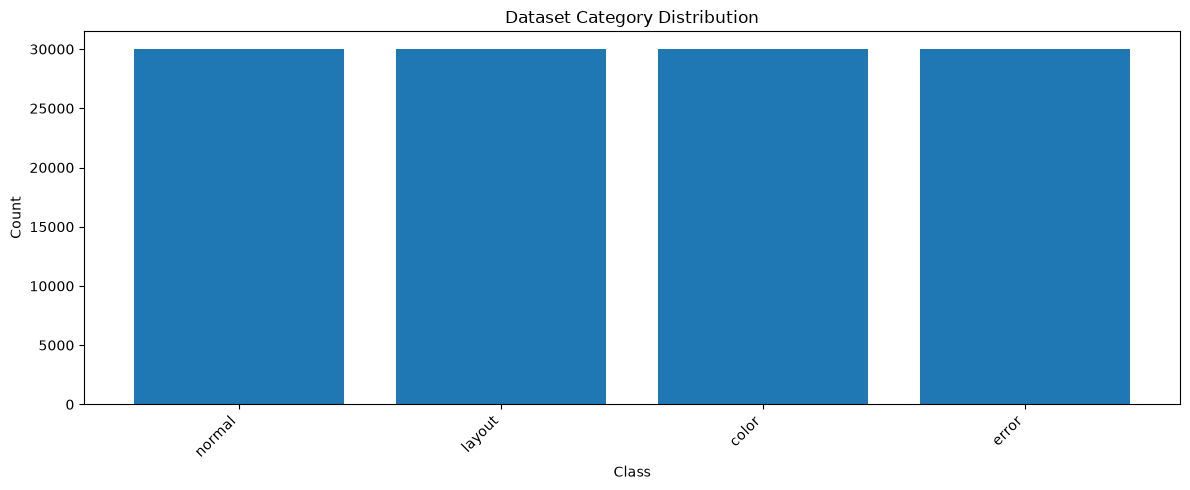

Saved chart: argus_model_outputs\charts\02_issue_label_distribution.png


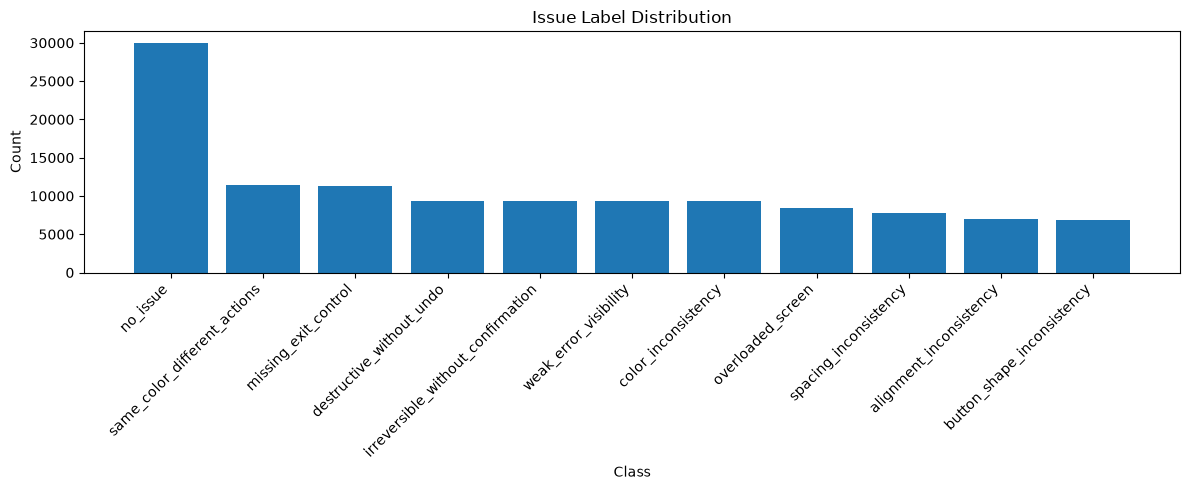

Saved chart: argus_model_outputs\charts\03_severity_distribution.png


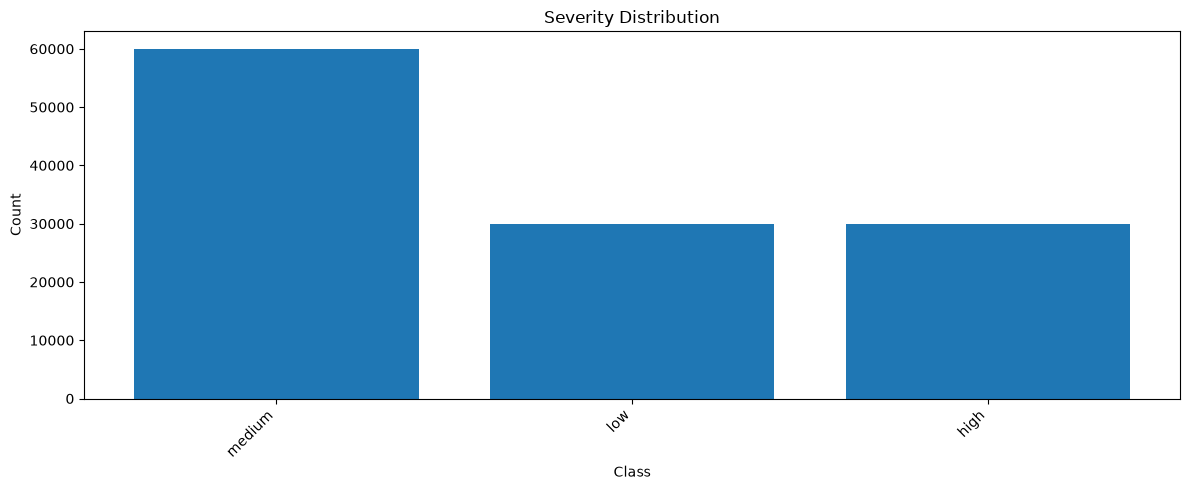

Saved chart: argus_model_outputs\charts\04_suggestion_category_distribution.png


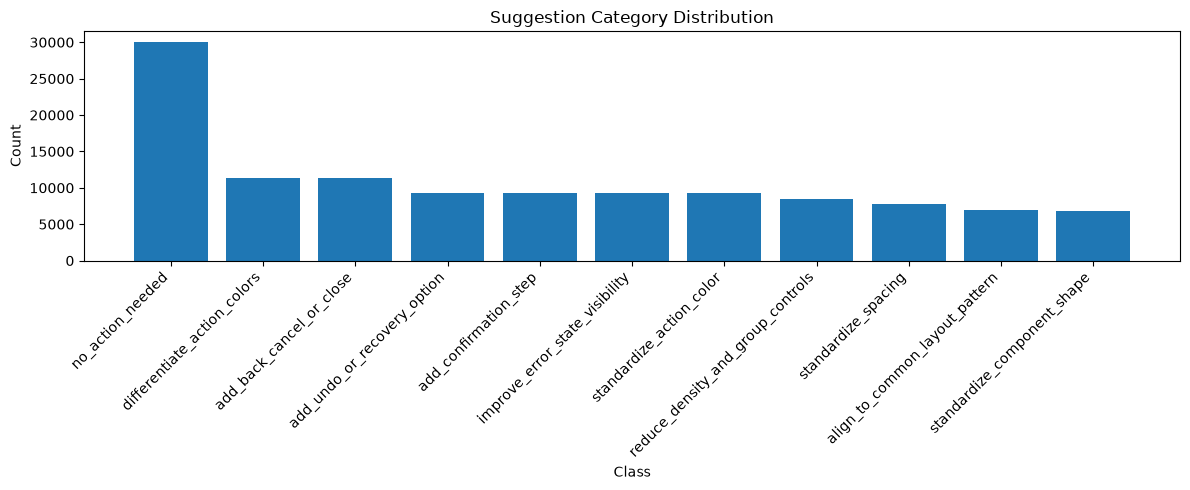

In [16]:
def save_current_chart(filename):
    path = CHART_DIR / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved chart:", path)


def plot_counts(series, title, filename):
    counts = series.value_counts()

    plt.figure(figsize=(12, 5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_current_chart(filename)
    plt.show()


plot_counts(df["category"], "Dataset Category Distribution", "01_dataset_category_distribution.png")
plot_counts(df["issueLabel"], "Issue Label Distribution", "02_issue_label_distribution.png")
plot_counts(df["severity"], "Severity Distribution", "03_severity_distribution.png")
plot_counts(df["suggestionCategory"], "Suggestion Category Distribution", "04_suggestion_category_distribution.png")

Saved chart: argus_model_outputs\charts\feature_distribution_01_nodeCount.png


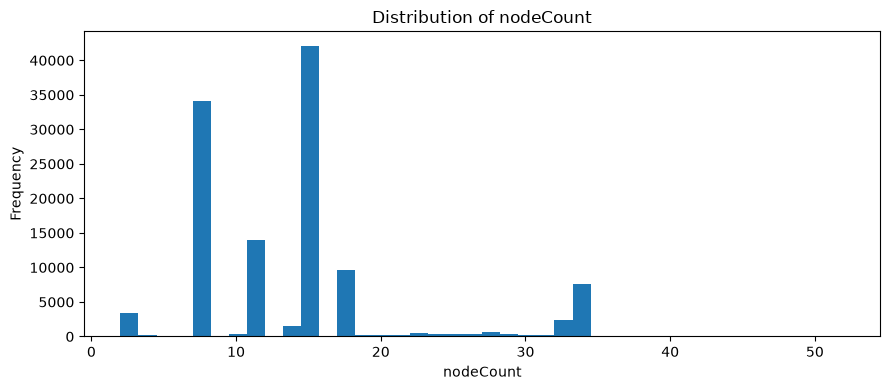

Saved chart: argus_model_outputs\charts\feature_distribution_02_controlDensity.png


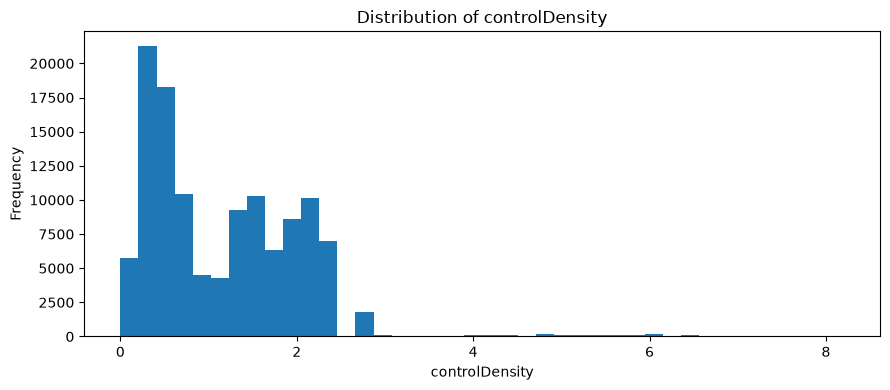

Saved chart: argus_model_outputs\charts\feature_distribution_03_textDensity.png


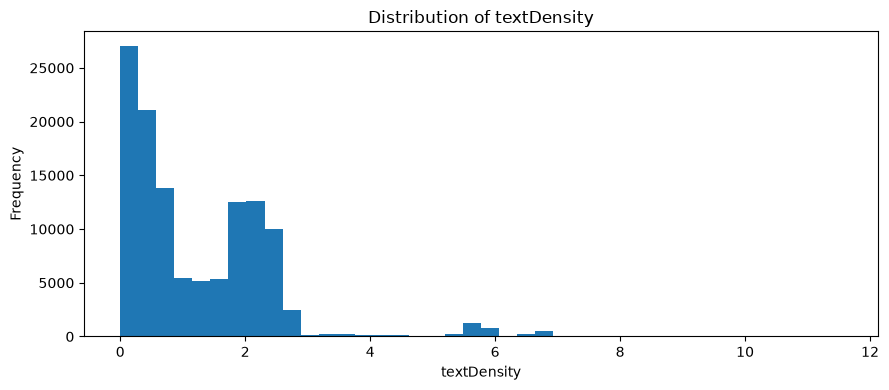

Saved chart: argus_model_outputs\charts\feature_distribution_04_spacingDeviation.png


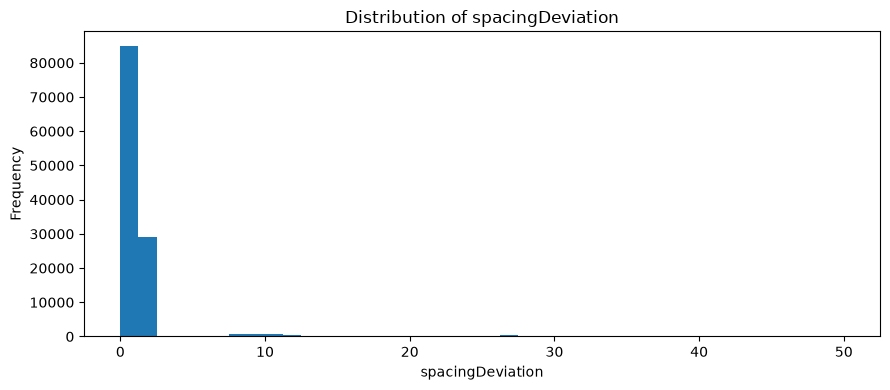

Saved chart: argus_model_outputs\charts\feature_distribution_05_alignmentDeviation.png


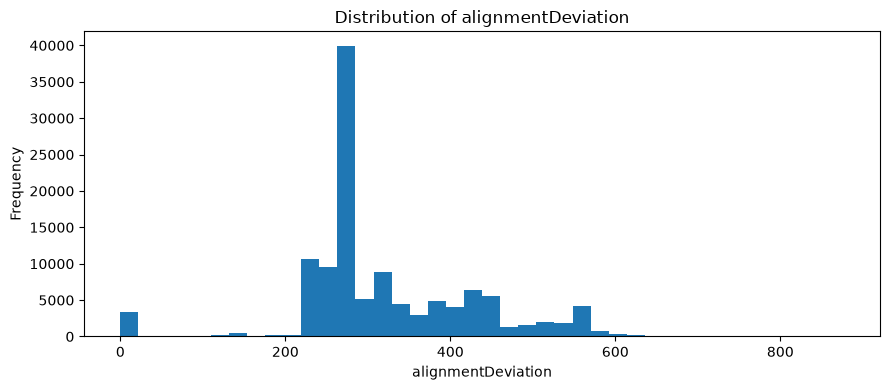

Saved chart: argus_model_outputs\charts\feature_distribution_06_cornerRadiusDeviation.png


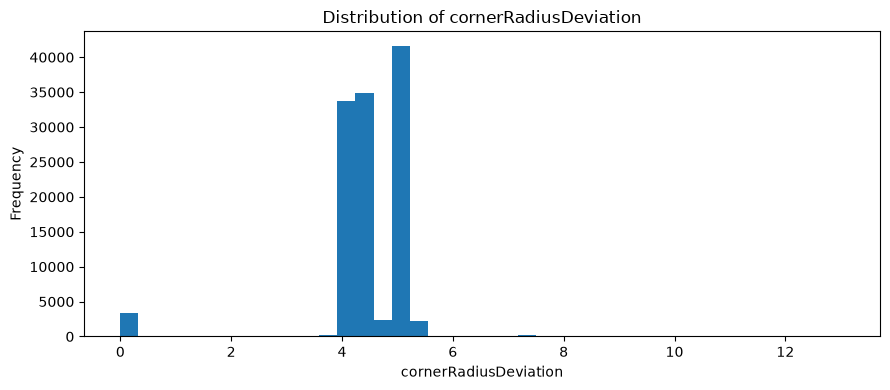

Saved chart: argus_model_outputs\charts\feature_distribution_07_buttonHeightDeviation.png


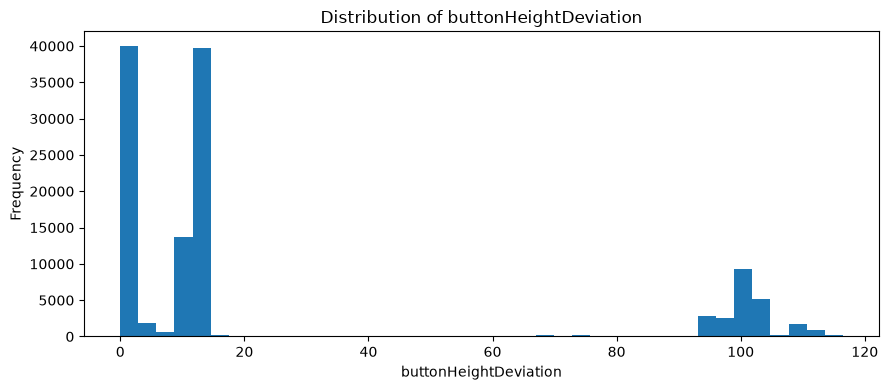

Saved chart: argus_model_outputs\charts\feature_distribution_08_buttonWidthDeviation.png


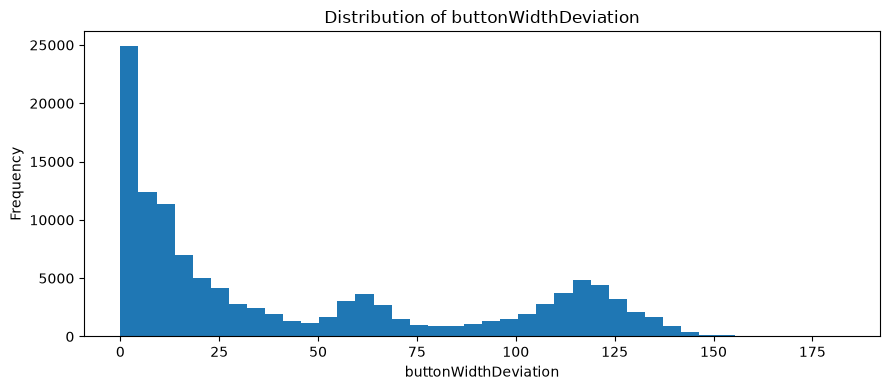

Saved chart: argus_model_outputs\charts\feature_distribution_09_colorCount.png


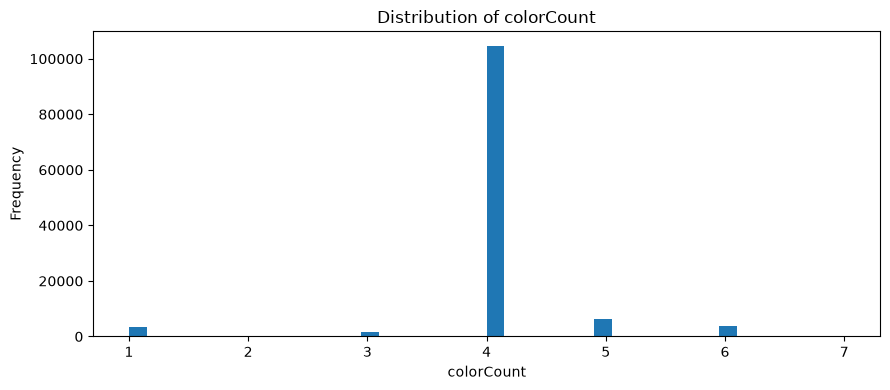

Saved chart: argus_model_outputs\charts\feature_distribution_10_colorPatternDeviation.png


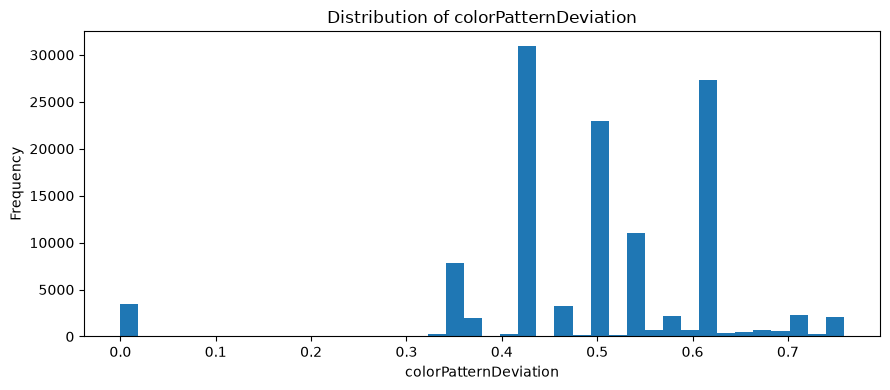

Saved chart: argus_model_outputs\charts\feature_distribution_11_errorContrastRatio.png


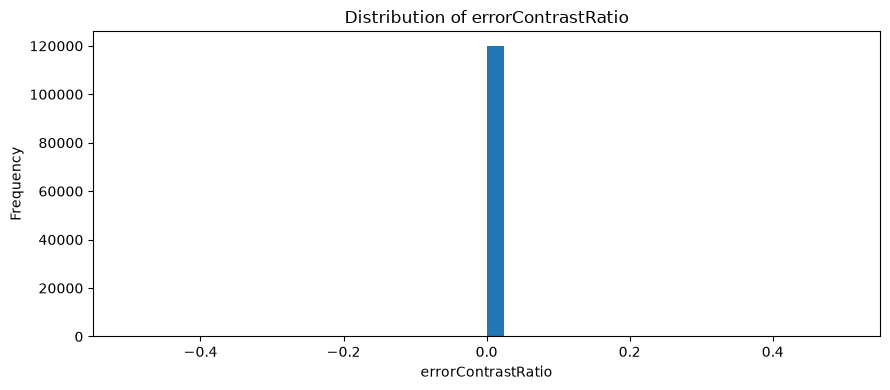

Saved chart: argus_model_outputs\charts\feature_distribution_12_errorVisibilityScore.png


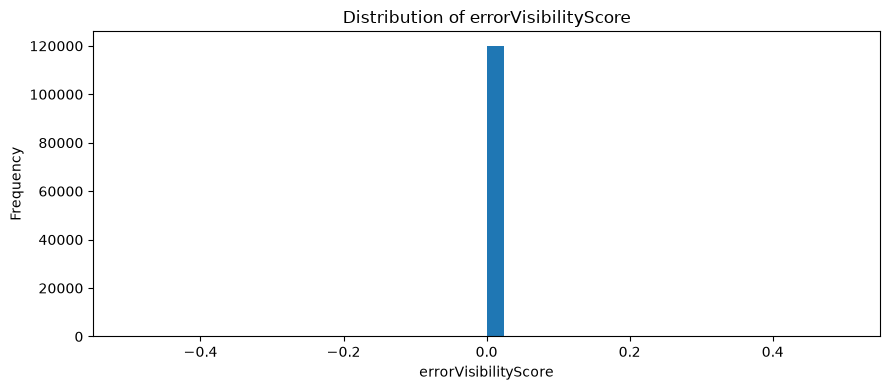

In [17]:
important_features = [
    "nodeCount",
    "controlDensity",
    "textDensity",
    "spacingDeviation",
    "alignmentDeviation",
    "cornerRadiusDeviation",
    "buttonHeightDeviation",
    "buttonWidthDeviation",
    "colorCount",
    "colorPatternDeviation",
    "errorContrastRatio",
    "errorVisibilityScore"
]

for i, feature in enumerate(important_features, start=1):
    plt.figure(figsize=(9, 4))
    plt.hist(df[feature].fillna(0), bins=40)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.tight_layout()
    save_current_chart(f"feature_distribution_{i:02d}_{feature}.png")
    plt.show()

Saved chart: argus_model_outputs\charts\05_feature_correlation_matrix.png


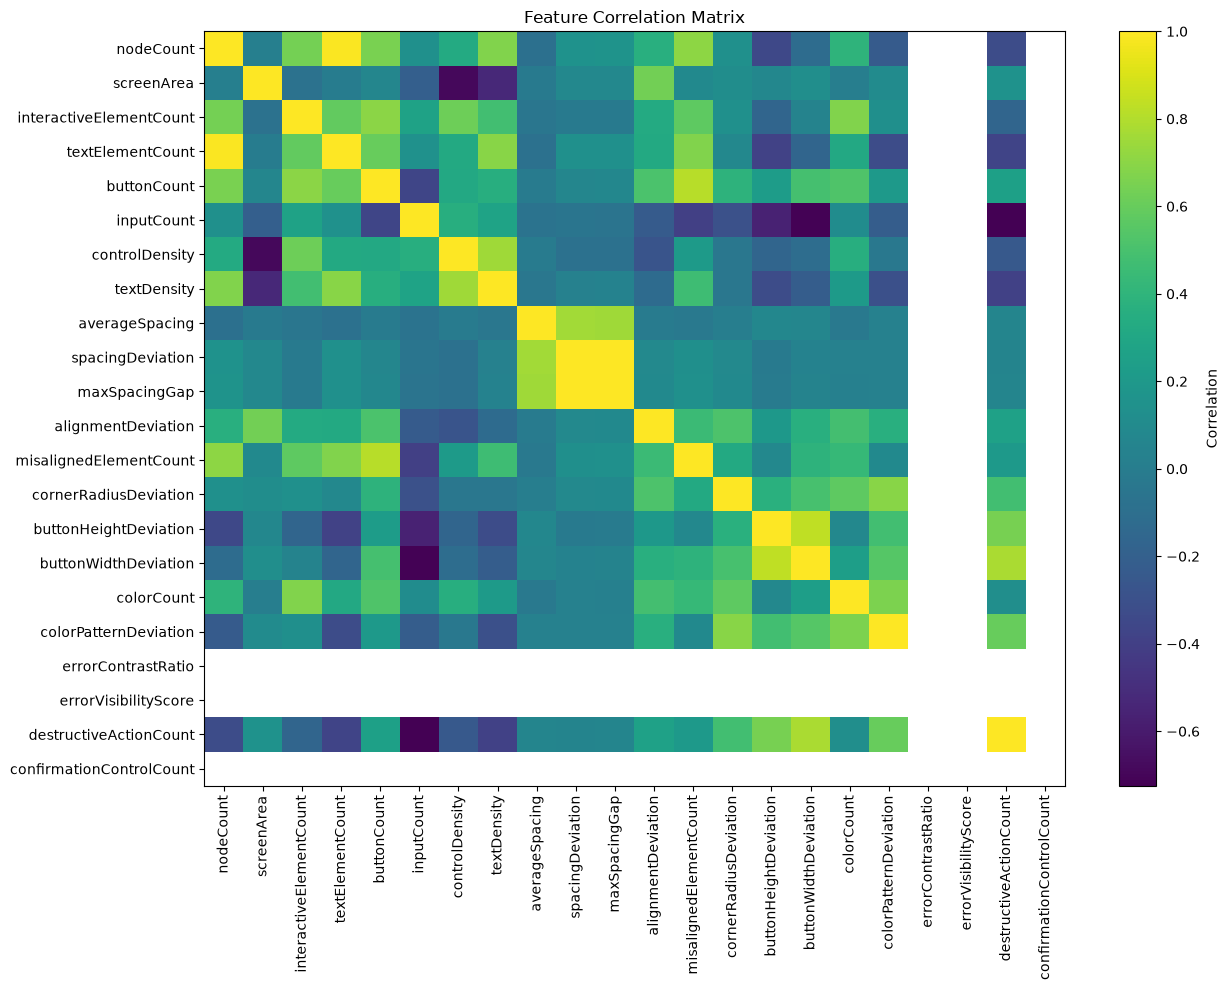

In [18]:
# ===============================
# Cell 15: Feature correlation matrix
# ===============================

selected_features = [
    "nodeCount", "screenArea", "interactiveElementCount", "textElementCount",
    "buttonCount", "inputCount", "controlDensity", "textDensity",
    "averageSpacing", "spacingDeviation", "maxSpacingGap",
    "alignmentDeviation", "misalignedElementCount",
    "cornerRadiusDeviation", "buttonHeightDeviation", "buttonWidthDeviation",
    "colorCount", "colorPatternDeviation",
    "errorContrastRatio", "errorVisibilityScore",
    "destructiveActionCount", "confirmationControlCount"
]

corr = df[selected_features].fillna(0).corr()

plt.figure(figsize=(13, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(selected_features)), selected_features, rotation=90)
plt.yticks(range(len(selected_features)), selected_features)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
save_current_chart("05_feature_correlation_matrix.png")
plt.show()

Saved chart: argus_model_outputs\charts\06_pca_issue_label_visualization.png


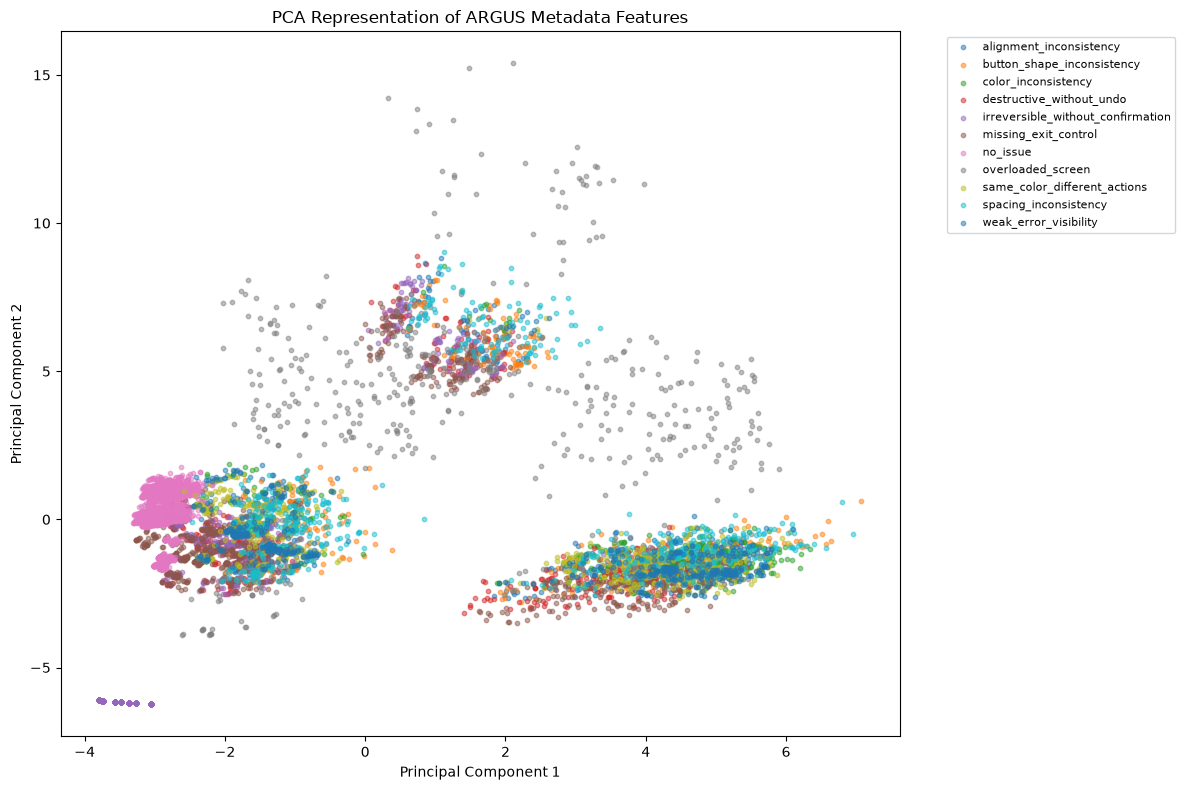

Explained variance ratio: [0.25747785 0.19858403]


In [19]:
sample_df = df.sample(min(8000, len(df)), random_state=42)

X_sample = sample_df[FEATURE_COLUMNS].fillna(0)
y_sample = sample_df["issueLabel"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

labels = sorted(y_sample.unique())

for label in labels:
    mask = y_sample == label
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=10,
        alpha=0.5,
        label=label
    )

plt.title("PCA Representation of ARGUS Metadata Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
save_current_chart("06_pca_issue_label_visualization.png")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

Saved chart: argus_model_outputs\charts\07_sample_design_wireframe_preview.png


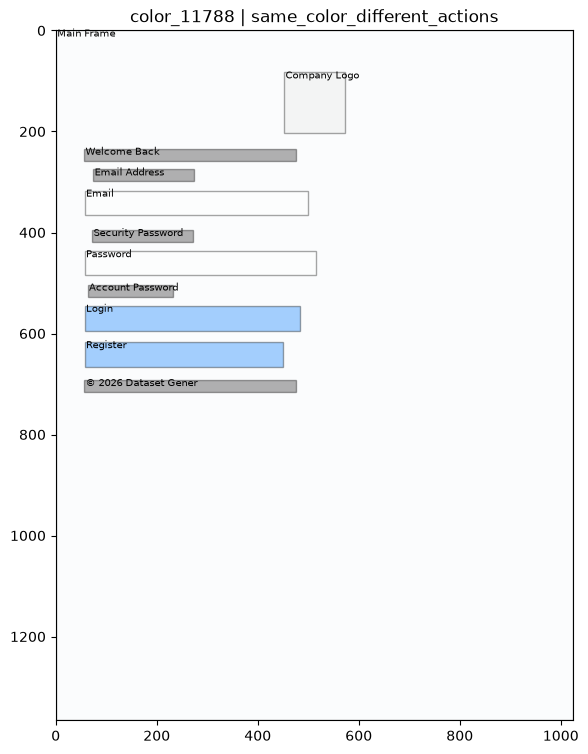

In [20]:
def load_design_by_id(design_id, category):
    design_path = f"dataset_Figma/designs/{category}/{design_id}.json"

    with zipfile.ZipFile(DATASET_ZIP, "r") as z:
        design = json.loads(z.read(design_path))

    return design


def draw_design(design, title="Design Preview"):
    nodes = design.get("nodes", [])

    if len(nodes) == 0:
        print("No nodes available.")
        return

    root = nodes[0]
    width = max(safe_number(root.get("width")), 1)
    height = max(safe_number(root.get("height")), 1)

    plt.figure(figsize=(6, 9))
    ax = plt.gca()

    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_title(title)

    for node in nodes:
        x = safe_number(node.get("x"))
        y = safe_number(node.get("y"))
        w = safe_number(node.get("width"))
        h = safe_number(node.get("height"))

        if w <= 0 or h <= 0:
            continue

        color = get_color(node)

        if color:
            fill = (color["r"] / 255, color["g"] / 255, color["b"] / 255)
        else:
            fill = (0.9, 0.9, 0.9)

        rect = plt.Rectangle(
            (x, y),
            w,
            h,
            linewidth=1,
            edgecolor="black",
            facecolor=fill,
            alpha=0.35
        )

        ax.add_patch(rect)

        label = node.get("text") or node.get("name") or node.get("type")

        if w > 50 and h > 20:
            ax.text(x + 3, y + 12, str(label)[:20], fontsize=7)

    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    save_current_chart("07_sample_design_wireframe_preview.png")
    plt.show()


sample_row = df.sample(1, random_state=42).iloc[0]

sample_design = load_design_by_id(
    design_id=sample_row["designId"],
    category=sample_row["category"]
)

draw_design(
    sample_design,
    title=f"{sample_row['designId']} | {sample_row['issueLabel']}"
)

In [21]:
X = df[FEATURE_COLUMNS].fillna(0)
y = df["issueLabel"]

# 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:", len(X_test))

print("\nTraining class distribution:")
display(y_train.value_counts())

Training rows: 83997
Validation rows: 18003
Test rows: 18000

Training class distribution:


issueLabel
no_issue                             20999
same_color_different_actions          7979
missing_exit_control                  7934
destructive_without_undo              6540
irreversible_without_confirmation     6525
weak_error_visibility                 6519
color_inconsistency                   6502
overloaded_screen                     5891
spacing_inconsistency                 5441
alignment_inconsistency               4887
button_shape_inconsistency            4780
Name: count, dtype: int64

In [22]:
# Train final model curve by tree count
tree_counts = [50, 100, 200, 300, 500, 700]

curve_results = []

for n_trees in tree_counts:
    print(f"Training ExtraTrees with {n_trees} trees...")

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesClassifier(
            n_estimators=n_trees,
            max_depth=None,
            min_samples_leaf=1,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    curve_results.append({
        "n_estimators": n_trees,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "train_macro_f1": f1_score(y_train, train_pred, average="macro"),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro")
    })

curve_df = pd.DataFrame(curve_results)

display(curve_df)

Training ExtraTrees with 50 trees...
Training ExtraTrees with 100 trees...
Training ExtraTrees with 200 trees...
Training ExtraTrees with 300 trees...
Training ExtraTrees with 500 trees...
Training ExtraTrees with 700 trees...


,n_estimators,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1
0,50,0.997667,0.746042,0.997272,0.695582
1,100,0.997667,0.744209,0.997272,0.693211
2,200,0.997667,0.744543,0.997272,0.693697
3,300,0.997667,0.745654,0.997272,0.695022
4,500,0.997667,0.744765,0.997272,0.693827
5,700,0.997667,0.745598,0.997272,0.694865


Saved chart: argus_model_outputs\charts\08_training_vs_validation_accuracy.png


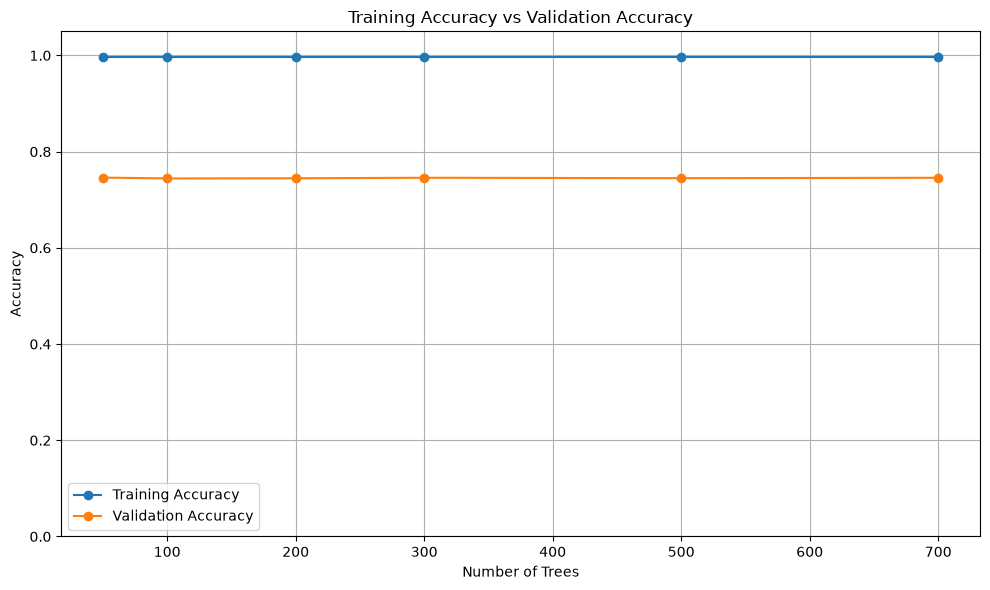

In [23]:
# Plot training vs validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(curve_df["n_estimators"], curve_df["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(curve_df["n_estimators"], curve_df["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
save_current_chart("08_training_vs_validation_accuracy.png")
plt.show()

Saved chart: argus_model_outputs\charts\09_training_vs_validation_macro_f1.png


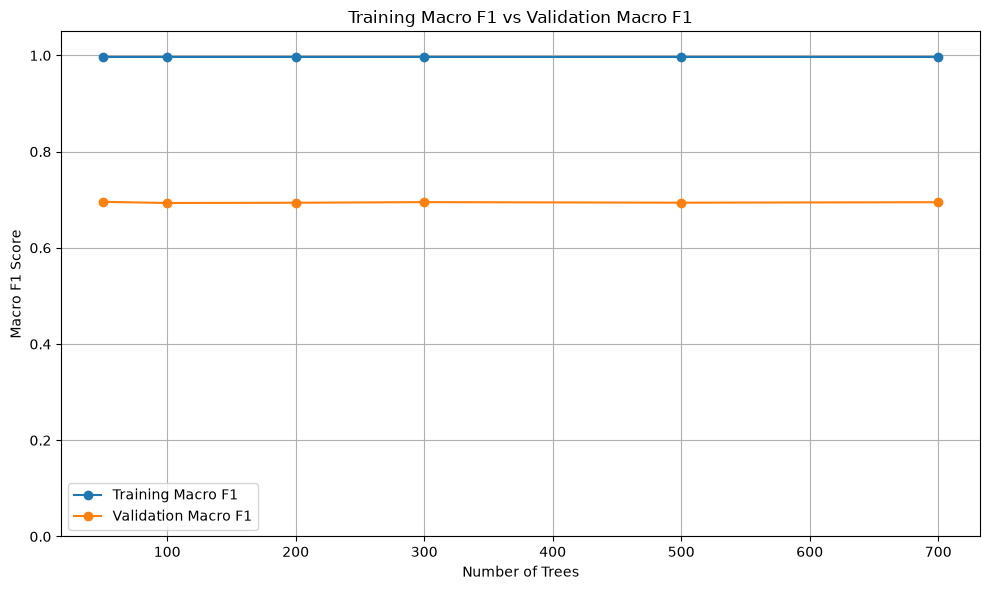

In [24]:
# Cell 21: Plot training vs validation macro F1
plt.figure(figsize=(10, 6))
plt.plot(curve_df["n_estimators"], curve_df["train_macro_f1"], marker="o", label="Training Macro F1")
plt.plot(curve_df["n_estimators"], curve_df["val_macro_f1"], marker="o", label="Validation Macro F1")
plt.title("Training Macro F1 vs Validation Macro F1")
plt.xlabel("Number of Trees")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
save_current_chart("09_training_vs_validation_macro_f1.png")
plt.show()

In [25]:
# Hyperparameter tuning for improved model
final_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

param_grid = {
    "model__n_estimators": [300, 500, 700, 900],
    "model__max_depth": [None, 20, 40, 60],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=final_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)

print("\nBest cross-validation macro F1:")
print(search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters:
{'model__n_estimators': 500, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 20}

Best cross-validation macro F1:
0.7015424392271221


,mean_train_score,mean_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,param_model__max_features
7,0.846534,0.701542,500,20,2,0.5
8,0.846826,0.701243,700,20,2,0.5
10,0.923580,0.697174,900,20,1,log2
11,0.886260,0.697002,700,40,2,sqrt
1,0.882015,0.695616,900,None,2,log2
9,0.881716,0.695500,700,None,2,log2
2,0.800795,0.695391,700,40,4,sqrt
0,0.800480,0.695218,500,60,4,sqrt
14,0.939759,0.693986,300,40,2,0.5
4,0.779255,0.693752,300,20,4,log2


Saved chart: argus_model_outputs\charts\10_hyperparameter_search_train_vs_cv_f1.png


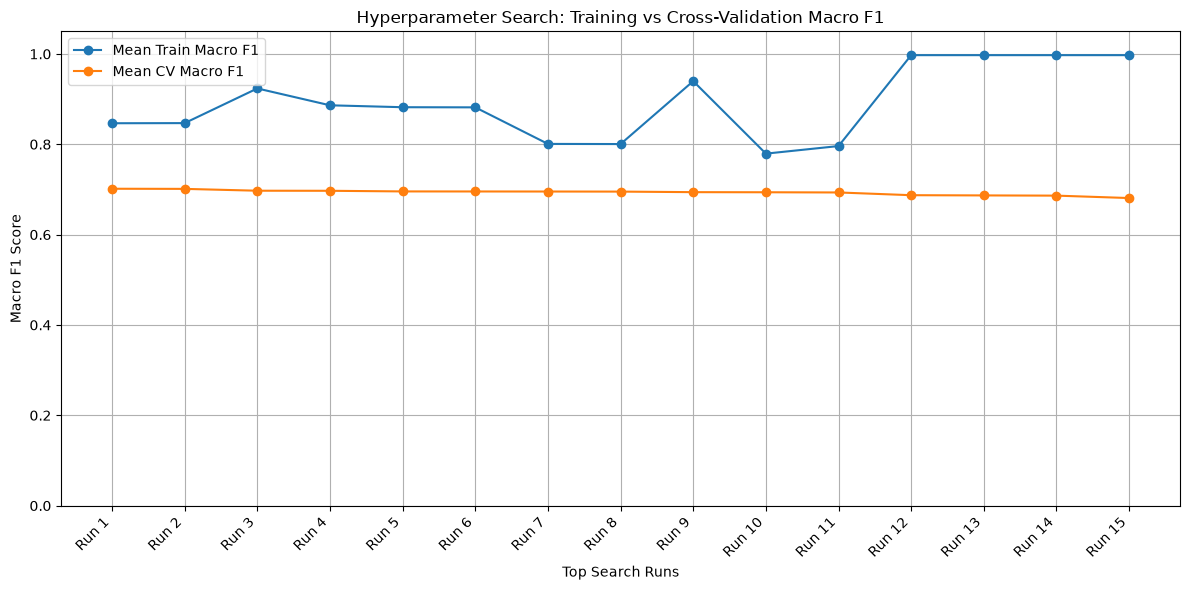

In [26]:
search_results = pd.DataFrame(search.cv_results_)

display(search_results[[
    "mean_train_score",
    "mean_test_score",
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_leaf",
    "param_model__max_features"
]].sort_values("mean_test_score", ascending=False).head(10))

top_results = search_results.sort_values("mean_test_score", ascending=False).head(15).copy()
top_results["rank_label"] = [f"Run {i+1}" for i in range(len(top_results))]

plt.figure(figsize=(12, 6))
plt.plot(top_results["rank_label"], top_results["mean_train_score"], marker="o", label="Mean Train Macro F1")
plt.plot(top_results["rank_label"], top_results["mean_test_score"], marker="o", label="Mean CV Macro F1")
plt.title("Hyperparameter Search: Training vs Cross-Validation Macro F1")
plt.xlabel("Top Search Runs")
plt.ylabel("Macro F1 Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
save_current_chart("10_hyperparameter_search_train_vs_cv_f1.png")
plt.show()

In [27]:
# Train final improved issue label model
best_issue_model = search.best_estimator_

# Refit best model on train + validation data for stronger final model
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

print("Final training rows:", len(X_train_final))

best_issue_model.fit(X_train_final, y_train_final)

print("Final improved issue-label model trained.")

Final training rows: 102000
Final improved issue-label model trained.


In [28]:
# Evaluate final model on test set
issue_pred = best_issue_model.predict(X_test)

test_accuracy = accuracy_score(y_test, issue_pred)
test_macro_f1 = f1_score(y_test, issue_pred, average="macro")
test_weighted_f1 = f1_score(y_test, issue_pred, average="weighted")

print("Final Test Accuracy:", test_accuracy)
print("Final Test Macro F1:", test_macro_f1)
print("Final Test Weighted F1:", test_weighted_f1)

print("\nClassification Report:")
print(classification_report(y_test, issue_pred, zero_division=0))

Final Test Accuracy: 0.7532222222222222
Final Test Macro F1: 0.7072001817450226
Final Test Weighted F1: 0.7552779454786777

Classification Report:
                                   precision    recall  f1-score   support

          alignment_inconsistency       0.56      0.89      0.69      1048
       button_shape_inconsistency       0.92      0.50      0.65      1024
              color_inconsistency       0.61      0.57      0.59      1393
         destructive_without_undo       0.59      0.62      0.60      1402
irreversible_without_confirmation       0.60      0.65      0.62      1398
             missing_exit_control       0.89      0.79      0.84      1700
                         no_issue       1.00      1.00      1.00      4500
                overloaded_screen       1.00      0.77      0.87      1262
     same_color_different_actions       0.63      0.48      0.54      1710
            spacing_inconsistency       0.84      0.93      0.88      1166
            weak_error_visi

,Metric,Score
0,Accuracy,0.753222
1,Macro F1,0.707200
2,Weighted F1,0.755278


Saved chart: argus_model_outputs\charts\11_final_test_performance_summary.png


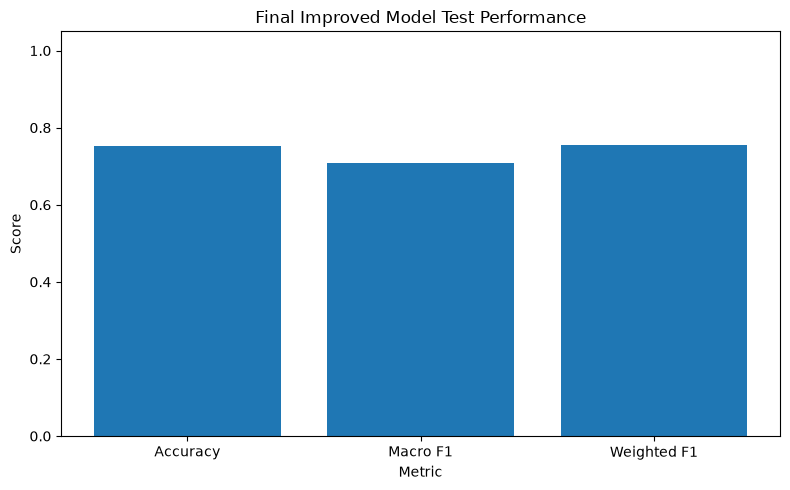

In [29]:
# Final performance summary chart
summary_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Weighted F1"],
    "Score": [test_accuracy, test_macro_f1, test_weighted_f1]
})

display(summary_metrics)

plt.figure(figsize=(8, 5))
plt.bar(summary_metrics["Metric"], summary_metrics["Score"])
plt.title("Final Improved Model Test Performance")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.tight_layout()
save_current_chart("11_final_test_performance_summary.png")
plt.show()

Saved chart: argus_model_outputs\charts\12_final_issue_label_confusion_matrix.png


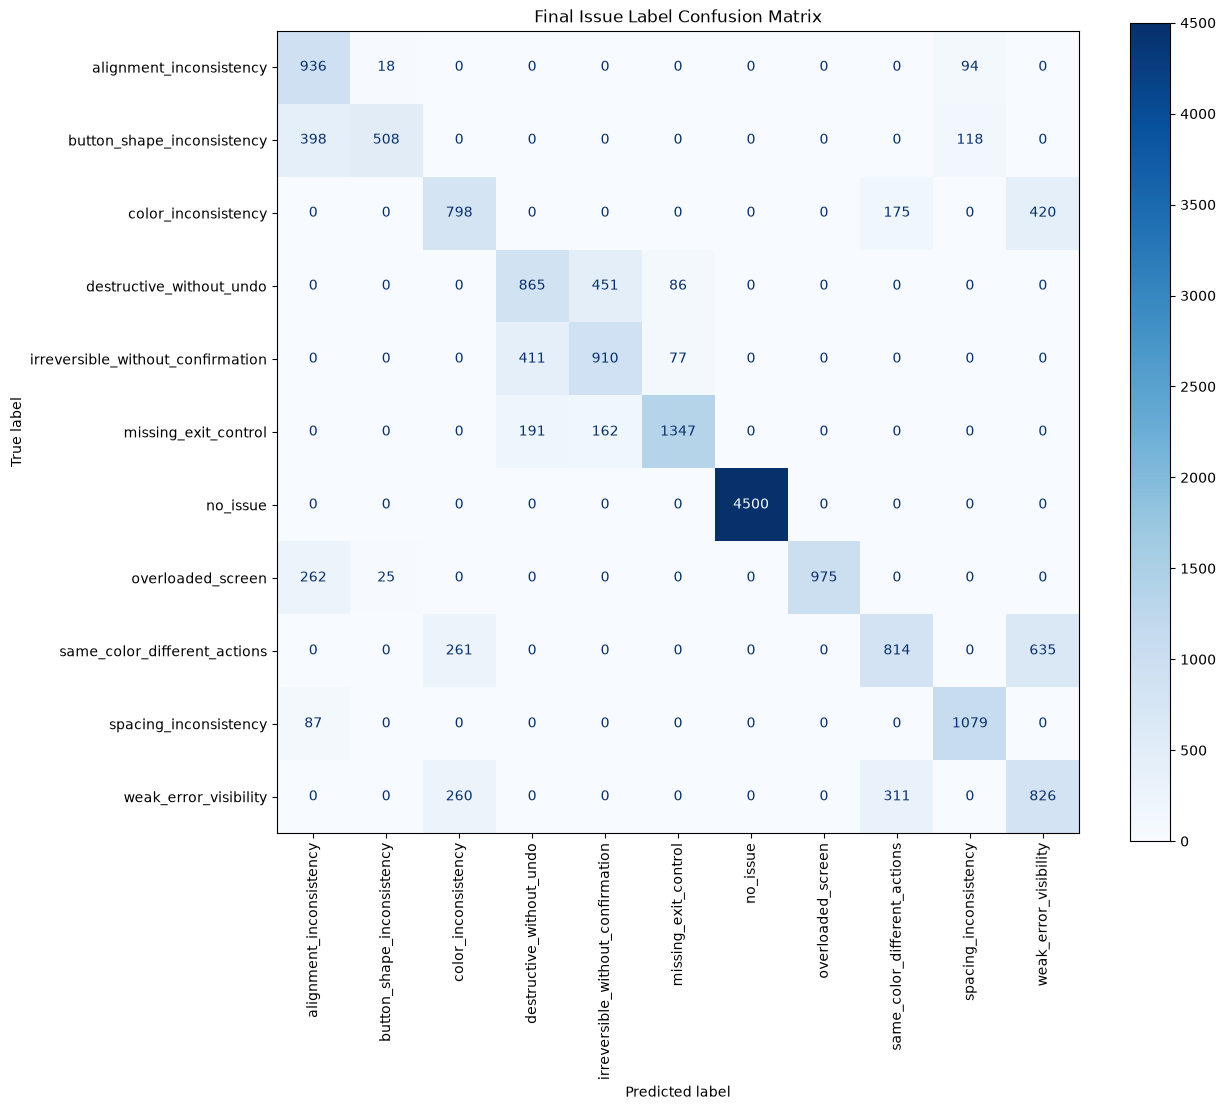

Saved chart: argus_model_outputs\charts\13_final_normalized_issue_label_confusion_matrix.png


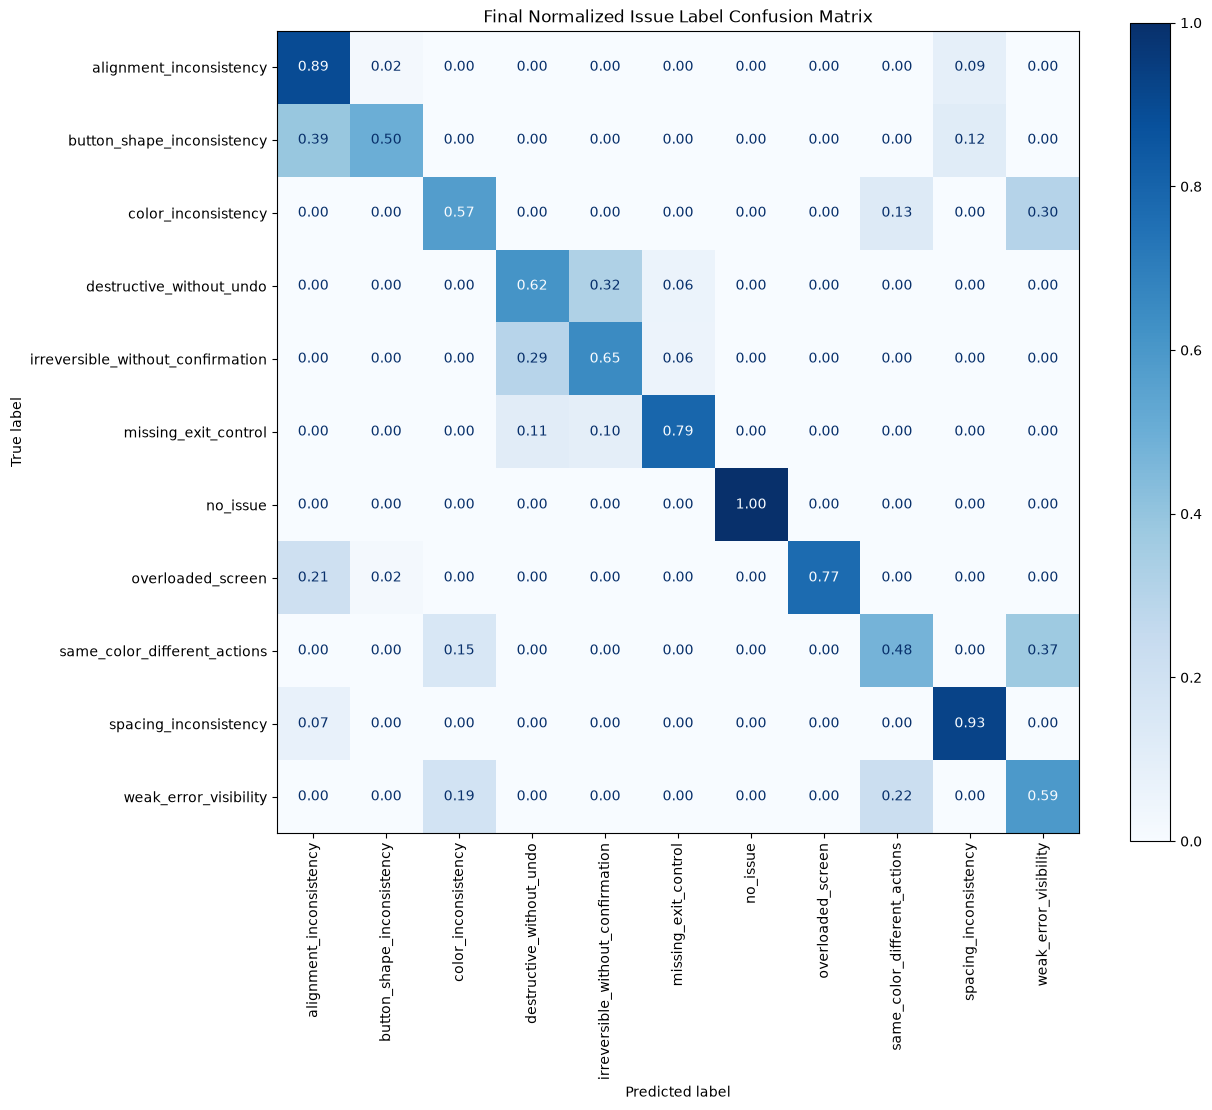

In [30]:
# Confusion matrix functions
def plot_confusion_matrix_custom(y_true, y_pred, title, filename, normalize=None, value_format="d"):
    labels = sorted(pd.Series(y_true).unique())

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
        normalize=normalize
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    fig, ax = plt.subplots(figsize=(13, 11))
    disp.plot(
        ax=ax,
        xticks_rotation=90,
        cmap="Blues",
        values_format=value_format,
        colorbar=True
    )
    plt.title(title)
    plt.tight_layout()
    save_current_chart(filename)
    plt.show()


plot_confusion_matrix_custom(
    y_test,
    issue_pred,
    "Final Issue Label Confusion Matrix",
    "12_final_issue_label_confusion_matrix.png",
    normalize=None,
    value_format="d"
)

plot_confusion_matrix_custom(
    y_test,
    issue_pred,
    "Final Normalized Issue Label Confusion Matrix",
    "13_final_normalized_issue_label_confusion_matrix.png",
    normalize="true",
    value_format=".2f"
)

,class,precision,recall,f1_score,support
0,alignment_inconsistency,0.556150,0.893130,0.685463,1048
1,button_shape_inconsistency,0.921960,0.496094,0.645079,1024
2,color_inconsistency,0.605004,0.572864,0.588496,1393
3,destructive_without_undo,0.589639,0.616976,0.602998,1402
4,irreversible_without_confirmation,0.597505,0.650930,0.623074,1398
5,missing_exit_control,0.892053,0.792353,0.839252,1700
6,no_issue,1.000000,1.000000,1.000000,4500
7,overloaded_screen,1.000000,0.772583,0.871703,1262
8,same_color_different_actions,0.626154,0.476023,0.540864,1710
9,spacing_inconsistency,0.835786,0.925386,0.878307,1166


Saved chart: argus_model_outputs\charts\14_classwise_precision_recall_f1.png


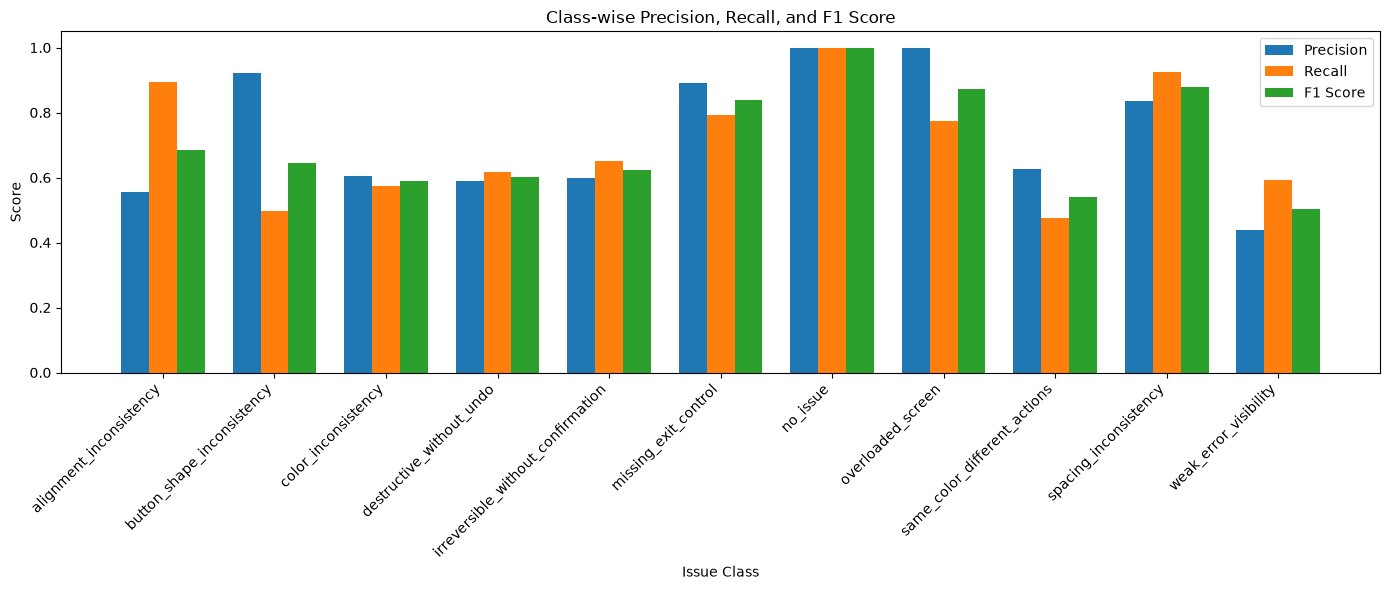

In [31]:
# Class wise precision, recall, F1
labels = sorted(pd.Series(y_test).unique())

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    issue_pred,
    labels=labels,
    zero_division=0
)

class_perf_df = pd.DataFrame({
    "class": labels,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
})

display(class_perf_df)

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, class_perf_df["precision"], width, label="Precision")
plt.bar(x, class_perf_df["recall"], width, label="Recall")
plt.bar(x + width, class_perf_df["f1_score"], width, label="F1 Score")
plt.xticks(x, labels, rotation=45, ha="right")
plt.title("Class-wise Precision, Recall, and F1 Score")
plt.xlabel("Issue Class")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
save_current_chart("14_classwise_precision_recall_f1.png")
plt.show()

In [32]:
# Misclassification table
error_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": issue_pred
})

wrong_df = error_df[error_df["actual"] != error_df["predicted"]].copy()

print("Total test samples:", len(error_df))
print("Wrong predictions:", len(wrong_df))
print("Error rate:", len(wrong_df) / len(error_df))

confusion_pairs = (
    wrong_df
    .value_counts(["actual", "predicted"])
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(confusion_pairs.head(25))

confusion_pairs.to_csv(OUTPUT_DIR / "misclassification_pairs.csv", index=False)
print("Saved misclassification table.")

Total test samples: 18000
Wrong predictions: 4442
Error rate: 0.2467777777777778


,actual,predicted,count
0,same_color_different_actions,weak_error_visibility,635
1,destructive_without_undo,irreversible_without_confirmation,451
2,color_inconsistency,weak_error_visibility,420
3,irreversible_without_confirmation,destructive_without_undo,411
4,button_shape_inconsistency,alignment_inconsistency,398
5,weak_error_visibility,same_color_different_actions,311
6,overloaded_screen,alignment_inconsistency,262
7,same_color_different_actions,color_inconsistency,261
8,weak_error_visibility,color_inconsistency,260
9,missing_exit_control,destructive_without_undo,191


Saved misclassification table.


Saved chart: argus_model_outputs\charts\15_top_misclassification_pairs.png


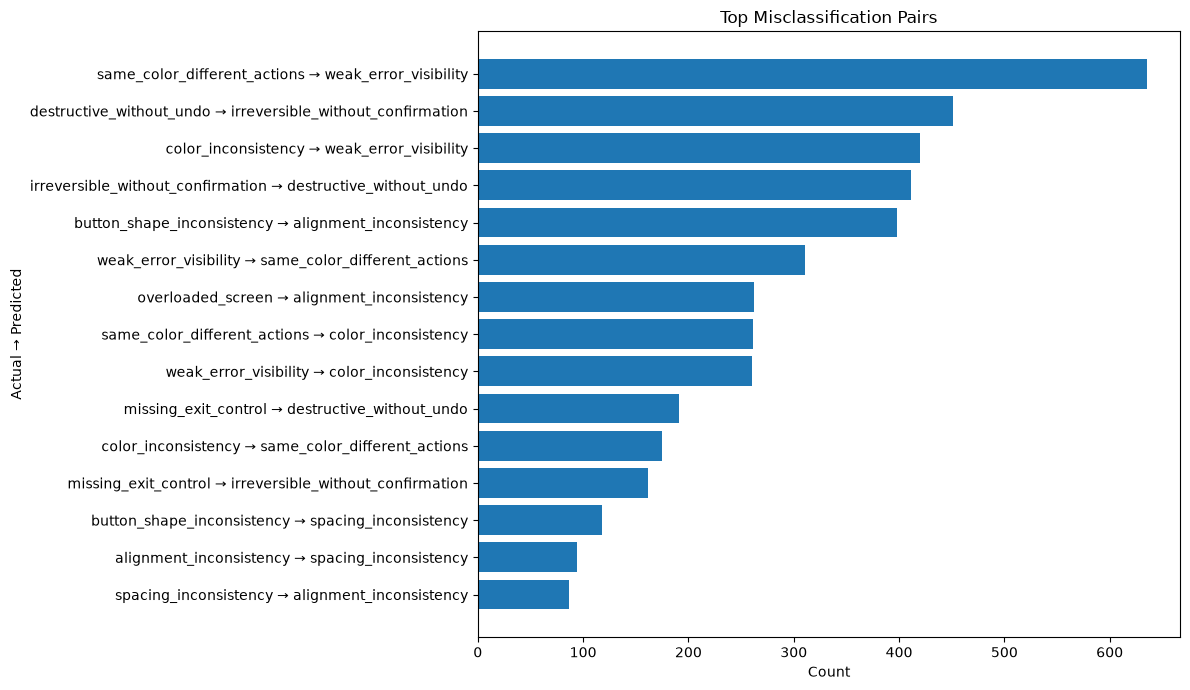

In [33]:
# Visualize top misclassification pairs
top_pairs = confusion_pairs.head(15).copy()

if len(top_pairs) > 0:
    top_pairs["pair"] = top_pairs["actual"] + " → " + top_pairs["predicted"]

    plt.figure(figsize=(12, 7))
    plt.barh(top_pairs["pair"], top_pairs["count"])
    plt.title("Top Misclassification Pairs")
    plt.xlabel("Count")
    plt.ylabel("Actual → Predicted")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    save_current_chart("15_top_misclassification_pairs.png")
    plt.show()
else:
    print("No misclassifications found.")

In [34]:
# Prediction confidence analysis
if hasattr(best_issue_model.named_steps["model"], "predict_proba"):
    probabilities = best_issue_model.predict_proba(X_test)
    classes = best_issue_model.named_steps["model"].classes_

    confidence = probabilities.max(axis=1)
    predicted_classes = classes[probabilities.argmax(axis=1)]

    confidence_df = pd.DataFrame({
        "actual": y_test.values,
        "predicted": predicted_classes,
        "confidence": confidence,
        "correct": y_test.values == predicted_classes
    })

    display(confidence_df.head())

    print("Average confidence:", confidence_df["confidence"].mean())
    print("Average confidence for correct predictions:", confidence_df[confidence_df["correct"]]["confidence"].mean())
    print("Average confidence for wrong predictions:", confidence_df[~confidence_df["correct"]]["confidence"].mean())
else:
    confidence_df = pd.DataFrame()
    print("Model does not support predict_proba.")

,actual,predicted,confidence,correct
0,no_issue,no_issue,1.000000,True
1,button_shape_inconsistency,alignment_inconsistency,0.608887,False
2,spacing_inconsistency,spacing_inconsistency,1.000000,True
3,no_issue,no_issue,1.000000,True
4,no_issue,no_issue,1.000000,True


Average confidence: 0.7753563171226622
Average confidence for correct predictions: 0.868135938186921
Average confidence for wrong predictions: 0.49217169254156784


Saved chart: argus_model_outputs\charts\16_prediction_confidence_distribution.png


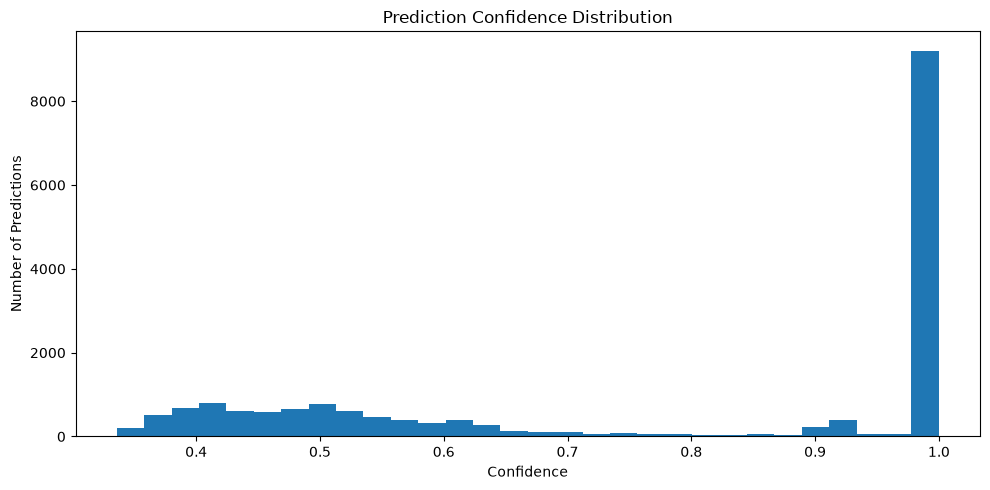

Saved chart: argus_model_outputs\charts\17_confidence_correct_vs_wrong.png


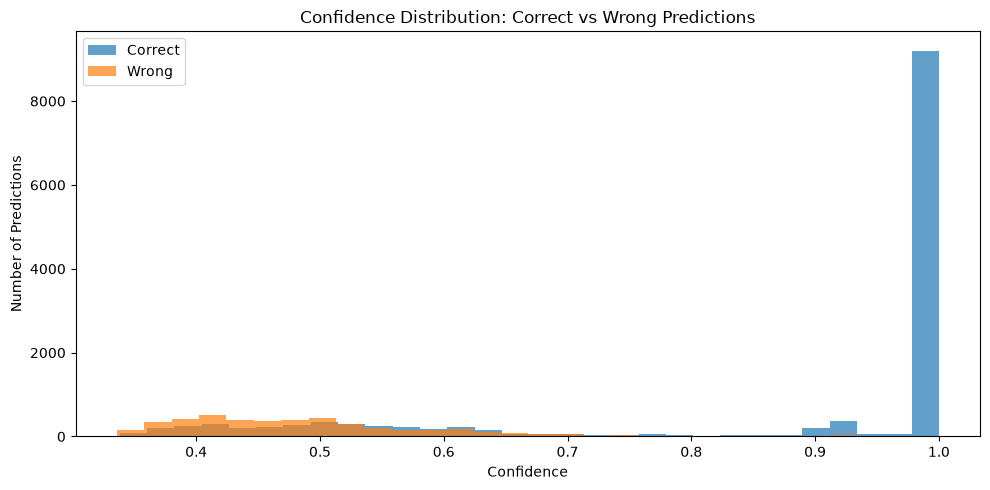

In [35]:
# Confidence distribution chart
if len(confidence_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.hist(confidence_df["confidence"], bins=30)
    plt.title("Prediction Confidence Distribution")
    plt.xlabel("Confidence")
    plt.ylabel("Number of Predictions")
    plt.tight_layout()
    save_current_chart("16_prediction_confidence_distribution.png")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.hist(confidence_df[confidence_df["correct"]]["confidence"], bins=30, alpha=0.7, label="Correct")
    plt.hist(confidence_df[~confidence_df["correct"]]["confidence"], bins=30, alpha=0.7, label="Wrong")
    plt.title("Confidence Distribution: Correct vs Wrong Predictions")
    plt.xlabel("Confidence")
    plt.ylabel("Number of Predictions")
    plt.legend()
    plt.tight_layout()
    save_current_chart("17_confidence_correct_vs_wrong.png")
    plt.show()

,confidence_band,accuracy,count,average_confidence
0,0-0.40,0.361509,1325,0.376001
1,0.40-0.55,0.419020,4427,0.472013
2,0.55-0.70,0.548760,1815,0.608043
3,0.70-0.85,0.664083,387,0.761131
4,0.85-1.00,0.992534,10046,0.992480


Saved chart: argus_model_outputs\charts\18_accuracy_by_confidence_band.png


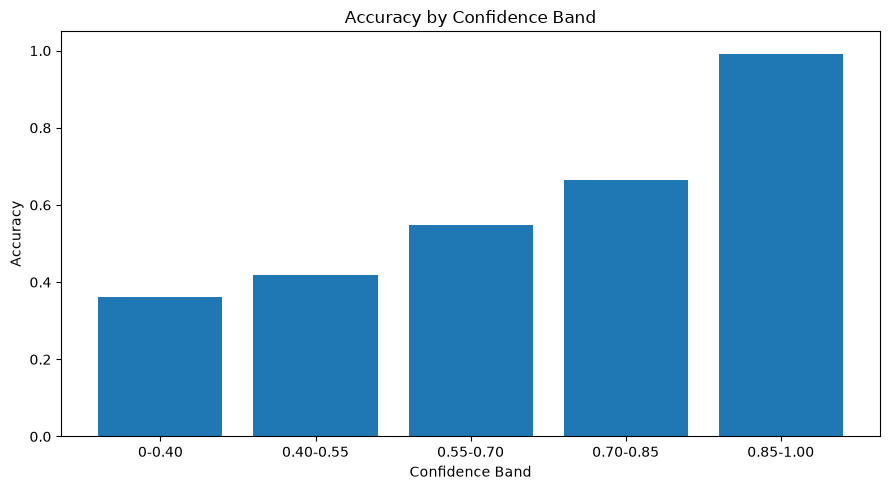

In [36]:
# Accuracy by confidence band
if len(confidence_df) > 0:
    bins = [0, 0.4, 0.55, 0.7, 0.85, 1.0]
    labels_band = ["0-0.40", "0.40-0.55", "0.55-0.70", "0.70-0.85", "0.85-1.00"]

    confidence_df["confidence_band"] = pd.cut(
        confidence_df["confidence"],
        bins=bins,
        labels=labels_band,
        include_lowest=True
    )

    band_accuracy = (
        confidence_df
        .groupby("confidence_band")
        .agg(
            accuracy=("correct", "mean"),
            count=("correct", "count"),
            average_confidence=("confidence", "mean")
        )
        .reset_index()
    )

    display(band_accuracy)

    plt.figure(figsize=(9, 5))
    plt.bar(band_accuracy["confidence_band"].astype(str), band_accuracy["accuracy"])
    plt.title("Accuracy by Confidence Band")
    plt.xlabel("Confidence Band")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    save_current_chart("18_accuracy_by_confidence_band.png")
    plt.show()

,feature,importance
41,module_normal,0.121641
38,module_layout,0.116553
39,module_color,0.107707
40,module_error,0.092054
26,colorCount,0.078907
22,cornerRadiusDeviation,0.054677
18,spacingDeviation,0.044267
30,colorPatternDeviation,0.043693
19,maxSpacingGap,0.042146
10,interactiveElementCount,0.040754


Saved chart: argus_model_outputs\charts\19_top_feature_importance.png


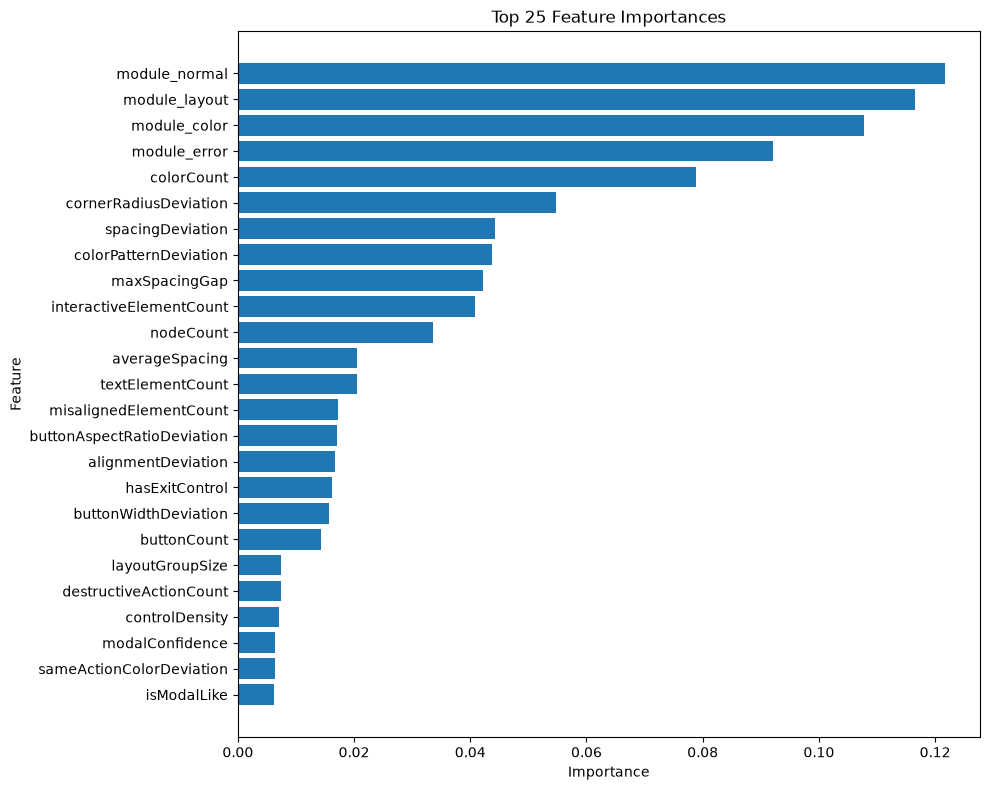

In [37]:
# Feature importance
trained_model = best_issue_model.named_steps["model"]

if hasattr(trained_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "importance": trained_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importance_df)

    importance_df.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

    top = importance_df.head(25)

    plt.figure(figsize=(10, 8))
    plt.barh(top["feature"], top["importance"])
    plt.title("Top 25 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    save_current_chart("19_top_feature_importance.png")
    plt.show()
else:
    print("This model does not provide feature importances.")

Actual issue: no_issue
Predicted issue: no_issue
Mapped severity: low
Mapped suggestion category: no_action_needed


,class,probability
6,no_issue,1.0
1,button_shape_inconsistency,0.0
0,alignment_inconsistency,0.0
2,color_inconsistency,0.0
3,destructive_without_undo,0.0
4,irreversible_without_confirmation,0.0
5,missing_exit_control,0.0
7,overloaded_screen,0.0
8,same_color_different_actions,0.0
9,spacing_inconsistency,0.0


Saved chart: argus_model_outputs\charts\20_single_prediction_probabilities.png


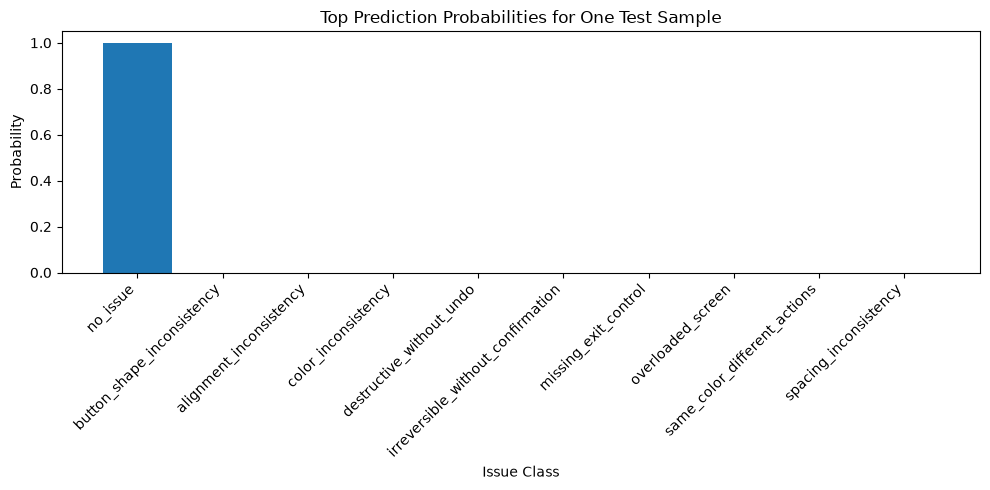

In [38]:
# Test one prediction with probabilities
sample_index = 0
test_row = X_test.iloc[[sample_index]]

actual_issue = y_test.iloc[sample_index]
predicted_issue = best_issue_model.predict(test_row)[0]

mapped_severity = SEVERITY_MAP.get(predicted_issue, "medium")
mapped_suggestion = SUGGESTION_MAP.get(predicted_issue, "review_ui_pattern")

print("Actual issue:", actual_issue)
print("Predicted issue:", predicted_issue)
print("Mapped severity:", mapped_severity)
print("Mapped suggestion category:", mapped_suggestion)

if hasattr(best_issue_model.named_steps["model"], "predict_proba"):
    sample_probabilities = best_issue_model.predict_proba(test_row)[0]
    classes = best_issue_model.named_steps["model"].classes_

    probability_df = pd.DataFrame({
        "class": classes,
        "probability": sample_probabilities
    }).sort_values("probability", ascending=False)

    display(probability_df)

    top_probabilities = probability_df.head(10)

    plt.figure(figsize=(10, 5))
    plt.bar(top_probabilities["class"], top_probabilities["probability"])
    plt.title("Top Prediction Probabilities for One Test Sample")
    plt.xlabel("Issue Class")
    plt.ylabel("Probability")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    save_current_chart("20_single_prediction_probabilities.png")
    plt.show()

,train_size,train_macro_f1_mean,train_macro_f1_std,validation_macro_f1_mean,validation_macro_f1_std
0,8000,0.925657,0.002662,0.686876,0.004410
1,26000,0.868721,0.002116,0.698513,0.003146
2,44000,0.849368,0.001823,0.701149,0.002395
3,62000,0.841070,0.002677,0.702597,0.002621
4,80000,0.834019,0.002360,0.702354,0.003181


Saved chart: argus_model_outputs\charts\21_learning_curve_macro_f1.png


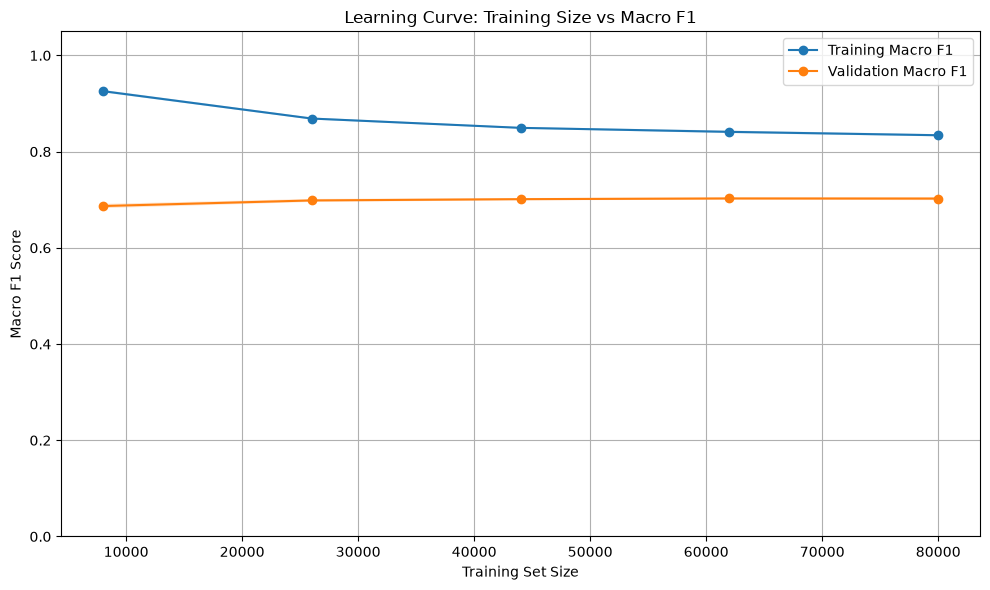

In [39]:
learning_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", ExtraTreesClassifier(
        n_estimators=search.best_params_.get("model__n_estimators", 500),
        max_depth=search.best_params_.get("model__max_depth", None),
        min_samples_leaf=search.best_params_.get("model__min_samples_leaf", 1),
        max_features=search.best_params_.get("model__max_features", "sqrt"),
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

train_sizes, train_scores, val_scores = learning_curve(
    learning_model,
    X,
    y,
    cv=3,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

learning_df = pd.DataFrame({
    "train_size": train_sizes,
    "train_macro_f1_mean": train_mean,
    "train_macro_f1_std": train_std,
    "validation_macro_f1_mean": val_mean,
    "validation_macro_f1_std": val_std
})

display(learning_df)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker="o", label="Training Macro F1")
plt.plot(train_sizes, val_mean, marker="o", label="Validation Macro F1")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.title("Learning Curve: Training Size vs Macro F1")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()
save_current_chart("21_learning_curve_macro_f1.png")
plt.show()

In [40]:
issue_report_dict = classification_report(
    y_test,
    issue_pred,
    zero_division=0,
    output_dict=True
)

metrics = {
    "modelVersion": "ARGUS Final Improved Structured Metadata Model",
    "trainingStrategy": "Final improved issue-label model with severity and suggestion mapping",
    "datasetRows": int(len(df)),
    "trainingRows": int(len(X_train_final)),
    "testRows": int(len(X_test)),
    "featureCount": int(len(FEATURE_COLUMNS)),
    "featureColumns": FEATURE_COLUMNS,
    "bestParameters": search.best_params_,
    "bestCrossValidationMacroF1": float(search.best_score_),
    "testAccuracy": float(test_accuracy),
    "testMacroF1": float(test_macro_f1),
    "testWeightedF1": float(test_weighted_f1),
    "issueLabelReport": issue_report_dict,
    "severityMapping": SEVERITY_MAP,
    "suggestionMapping": SUGGESTION_MAP,
    "issueLabels": sorted(df["issueLabel"].unique().tolist()),
    "useIssueMappingForDeployment": True
}

METRICS_PATH = MODEL_DIR / "model_metrics.json"

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

print("Saved metrics:", METRICS_PATH.resolve())

Saved metrics: C:\Users\User\Desktop\ARGUS_V6\Argus_Project _V6\argus_backend\ml_training\argus_model_outputs\model_files\model_metrics.json


In [41]:
MODEL_PATH = MODEL_DIR / "trained_ui_model.pkl"
COLUMNS_PATH = MODEL_DIR / "model_columns.json"

model_bundle = {
    "modelVersion": "ARGUS Final Improved Structured Metadata Model",
    "issue_model": best_issue_model,
    "feature_columns": FEATURE_COLUMNS,
    "severity_map": SEVERITY_MAP,
    "suggestion_map": SUGGESTION_MAP,
    "use_issue_mapping_for_deployment": True,
    "metrics": metrics
}

joblib.dump(model_bundle, MODEL_PATH, compress=3)

with open(COLUMNS_PATH, "w", encoding="utf-8") as file:
    json.dump(FEATURE_COLUMNS, file, indent=2)

print("Saved model:", MODEL_PATH.resolve())
print("Saved columns:", COLUMNS_PATH.resolve())

Saved model: C:\Users\User\Desktop\ARGUS_V6\Argus_Project _V6\argus_backend\ml_training\argus_model_outputs\model_files\trained_ui_model.pkl
Saved columns: C:\Users\User\Desktop\ARGUS_V6\Argus_Project _V6\argus_backend\ml_training\argus_model_outputs\model_files\model_columns.json


In [42]:
# ===============================
# Cell 39: Create final improved predict_ui_issue.py
# ===============================

predict_script = r'''
import sys
import json
import joblib
import numpy as np
from pathlib import Path

CURRENT_DIR = Path(__file__).resolve().parent

MODEL_PATH = CURRENT_DIR / "trained_ui_model.pkl"
COLUMNS_PATH = CURRENT_DIR / "model_columns.json"

def safe_number(value):
    try:
        if value is None:
            return 0.0
        value = float(value)
        if np.isnan(value) or np.isinf(value):
            return 0.0
        return value
    except:
        return 0.0

def load_model_bundle():
    return joblib.load(MODEL_PATH)

def load_feature_columns(model_bundle):
    if "feature_columns" in model_bundle:
        return model_bundle["feature_columns"]

    if COLUMNS_PATH.exists():
        with open(COLUMNS_PATH, "r", encoding="utf-8") as file:
            return json.load(file)

    raise ValueError("Feature columns were not found.")

def build_feature_row(input_data, feature_columns):
    row = []
    for column in feature_columns:
        row.append(safe_number(input_data.get(column, 0)))
    return [row]

def main():
    try:
        if len(sys.argv) < 2:
            raise ValueError("Input JSON argument is required.")

        input_data = json.loads(sys.argv[1])

        model_bundle = load_model_bundle()
        feature_columns = load_feature_columns(model_bundle)

        issue_model = model_bundle["issue_model"]
        severity_map = model_bundle.get("severity_map", {})
        suggestion_map = model_bundle.get("suggestion_map", {})

        X = build_feature_row(input_data, feature_columns)

        issue_label = issue_model.predict(X)[0]

        confidence_score = 0.0
        probability_details = {}

        if hasattr(issue_model.named_steps["model"], "predict_proba"):
            probabilities = issue_model.predict_proba(X)[0]
            classes = issue_model.named_steps["model"].classes_

            probability_details = {
                str(label): float(prob)
                for label, prob in zip(classes, probabilities)
            }

            confidence_score = float(max(probabilities))

        severity = severity_map.get(issue_label, "medium")
        suggestion_category = suggestion_map.get(issue_label, "review_ui_pattern")

        output = {
            "issueLabel": str(issue_label),
            "severity": str(severity),
            "suggestionCategory": str(suggestion_category),
            "confidenceScore": confidence_score,
            "probabilities": probability_details,
            "modelVersion": model_bundle.get("modelVersion", "ARGUS Final Improved Structured Metadata Model")
        }

        print(json.dumps(output))

    except Exception as error:
        fallback = {
            "issueLabel": "review_required",
            "severity": "medium",
            "suggestionCategory": "review_ui_pattern",
            "confidenceScore": 0.0,
            "error": str(error)
        }

        print(json.dumps(fallback))

if __name__ == "__main__":
    main()
'''

PREDICT_SCRIPT_PATH = MODEL_DIR / "predict_ui_issue.py"

with open(PREDICT_SCRIPT_PATH, "w", encoding="utf-8") as file:
    file.write(predict_script.strip())

print("Saved prediction script:", PREDICT_SCRIPT_PATH.resolve())

Saved prediction script: C:\Users\User\Desktop\ARGUS_V6\Argus_Project _V6\argus_backend\ml_training\argus_model_outputs\model_files\predict_ui_issue.py


In [43]:
# Copy model files to backend ml_training folder
ARGUS_BACKEND_ML_FOLDER = Path(r"C:\Users\94715\Desktop\Argus_Project\argus_backend\ml_training")

COPY_TO_BACKEND = False

if COPY_TO_BACKEND:
    ARGUS_BACKEND_ML_FOLDER.mkdir(parents=True, exist_ok=True)

    shutil.copy(MODEL_PATH, ARGUS_BACKEND_ML_FOLDER / "trained_ui_model.pkl")
    shutil.copy(COLUMNS_PATH, ARGUS_BACKEND_ML_FOLDER / "model_columns.json")
    shutil.copy(METRICS_PATH, ARGUS_BACKEND_ML_FOLDER / "model_metrics.json")
    shutil.copy(PREDICT_SCRIPT_PATH, ARGUS_BACKEND_ML_FOLDER / "predict_ui_issue.py")

    print("Copied final improved model files to:")
    print(ARGUS_BACKEND_ML_FOLDER)
else:
    print("COPY_TO_BACKEND is False. Set it to True when you want to copy files.")

COPY_TO_BACKEND is False. Set it to True when you want to copy files.
